# 1. COMPRENSIÓN DEL PROBLEMA Y LOS DATOS

## Objetivo del estudio

El objetivo de este trabajo es analizar la evolución del sistema energético mundial entre los años 2000 y 2019 usando técnicas de análisis exploratorio de datos y modelos de aprendizaje automático. En concreto, se busca analizar cómo ha evolucionado el consumo energético a nivel global, identificar qué factores estructurales están detrás de las emisiones de CO₂, estudiar los principales determinantes del consumo energético per cápita y construir modelos para predecir estas dos variables.

## Naturaleza del dataset

El dataset tiene estructura de panel data, lo que significa que tenemos múltiples países observados a lo largo del tiempo. La unidad de observación es el par país–año con el periodo cubierto de 2000 a 2020.

Las variables incluyen indicadores energéticos (generación eléctrica por tipo de fuente, consumo total, capacidad instalada renovable), económicos (PIB per cápita, crecimiento del PIB), ambientales (emisiones de CO₂) y geográficos (superficie, latitud, longitud, densidad de población).

## 2. IMPORTACIÓN DE LIBRERÍAS

In [1]:
# Importación de librerías

# Manipulación y análisis de datos
import numpy as np        # operaciones numéricas y álgebra lineal
import pandas as pd       # manejo de tablas de datos (DataFrames)

# Visualización
import matplotlib.pyplot as plt   # gráficos básicos (líneas, barras, dispersión...)
import seaborn as sns             # gráficos estadísticos más elaborados (construido sobre matplotlib)

# Análisis estadístico
# variance_inflation_factor: calcula el VIF para detectar multicolinealidad entre predictores
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson         # test de autocorrelación en residuos
from statsmodels.stats.diagnostic import het_breuschpagan    # test de Breusch-Pagan (heterocedasticidad)
import statsmodels.api as sm                                  # para añadir constante en Breusch-Pagan

# Preprocesamiento
# StandardScaler: estandariza variables para que tengan media=0 y desviación=1
# Es especialmente importante para la regresión de Ridge, como se verá más adelante
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Validación y selección de hiperparámetros
# GridSearchCV: prueba sistemáticamente distintos valores de un hiperparámetro
# usando validación cruzada para elegir el que mejor generaliza
from sklearn.model_selection import GridSearchCV

# Métricas de evaluación
# r2_score: coeficiente de determinación (proporción de variabilidad explicada)
# mean_absolute_error: error medio absoluto en las unidades de la variable objetivo
# mean_squared_error: error cuadrático medio (penaliza más los errores grandes)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configuración estética para los gráficos (fondo blanco con rejilla)
sns.set(style="whitegrid")

En esta sección se importan las librerías que se van a usar a lo largo del trabajo:

- `numpy` y `pandas` son las librerías base para trabajar con datos numéricos y tablas en Python.
- `matplotlib` y `seaborn` se usan para hacer los gráficos del análisis exploratorio.
- De `statsmodels` se importan las herramientas de diagnóstico estadístico: el VIF para detectar multicolinealidad, el test de Durbin-Watson para detectar autocorrelación en residuos, y el test de Breusch-Pagan para detectar heterocedasticidad.
- De `scikit-learn` se importan las herramientas de modelado: los propios modelos (LinearRegression, Ridge, RandomForestRegressor), el escalador estándar (StandardScaler), la búsqueda de hiperparámetros (GridSearchCV) y las métricas de evaluación (r2_score, mean_absolute_error, mean_squared_error).

---
**Notas adicionales**

scikit-learn es la librería de referencia para machine learning en Python. Su estructura está muy estandarizada: todos los modelos tienen los mismos métodos (.fit() para entrenar, .predict() para predecir), lo que hace sencillo cambiar de un modelo a otro.


## 3. CARGA E INSPECCIÓN INICIAL

Se cargan los datos y echamos un primer vistazo para entender con qué estamos trabajando: número de filas y columnas del dataset, qué tipo de variables tenemos, si hay datos faltantes y si hay filas duplicadas.

In [2]:
# Carga del dataset e inspección inicial

# Cargamos el CSV con pd.read_csv, que convierte el archivo en un DataFrame de pandas
df = pd.read_csv("/content/global-data-on-sustainable-energy (1).csv")

# df.shape devuelve una tupla (filas, columnas) que nos dice el tamaño del dataset
print("Dimensión inicial del dataset:", df.shape)

# df.head() muestra las 5 primeras filas para hacerse una idea visual de los datos, y comprobar
# que se hayan importado correctamente
display(df.head())

# df.info() muestra el tipo de dato de cada columna y cuántos valores no nulos hay
# Es fundamental para detectar columnas con NaN o con tipos incorrectos (p.ej. una columna
# numérica que Python ha leído como texto porque tenía algún carácter extraño)
print("\nTipos de datos y valores no nulos:")
df.info()

# df.describe() calcula estadísticas básicas de todas las variables numéricas:
# media, desviación típica, mínimo, máximo y percentiles 25, 50 y 75
# .transpose() gira la tabla para que cada variable sea una fila, facilitando la lectura
print("\nResumen estadístico:")
display(df.describe().transpose())

# df.duplicated().sum() cuenta cuántas filas son exactamente iguales a otra fila
# En datos tipo panel data no debería haber duplicados (cada combinación país-año es única)
print("\nNúmero de filas duplicadas:", df.duplicated().sum())

Dimensión inicial del dataset: (3649, 21)


,Entity,Year,Access to electricity (% of population),Access to clean fuels for cooking,Renewable-electricity-generating-capacity-per-capita,Financial flows to developing countries (US $),Renewable energy share in the total final energy consumption (%),Electricity from fossil fuels (TWh),Electricity from nuclear (TWh),Electricity from renewables (TWh),...,Primary energy consumption per capita (kWh/person),Energy intensity level of primary energy (MJ/$2017 PPP GDP),Value_co2_emissions_kt_by_country,Renewables (% equivalent primary energy),gdp_growth,gdp_per_capita,Density\n(P/Km2),Land Area(Km2),Latitude,Longitude
0,Afghanistan,2000,1.613591,6.2,9.22,20000.0,44.99,0.16,0.0,0.31,...,302.59482,1.64,760.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
1,Afghanistan,2001,4.074574,7.2,8.86,130000.0,45.60,0.09,0.0,0.50,...,236.89185,1.74,730.000000,NaN,NaN,NaN,60,652230.0,33.93911,67.709953
2,Afghanistan,2002,9.409158,8.2,8.47,3950000.0,37.83,0.13,0.0,0.56,...,210.86215,1.40,1029.999971,NaN,NaN,179.426579,60,652230.0,33.93911,67.709953
3,Afghanistan,2003,14.738506,9.5,8.09,25970000.0,36.66,0.31,0.0,0.63,...,229.96822,1.40,1220.000029,NaN,8.832278,190.683814,60,652230.0,33.93911,67.709953
4,Afghanistan,2004,20.064968,10.9,7.75,NaN,44.24,0.33,0.0,0.56,...,204.23125,1.20,1029.999971,NaN,1.414118,211.382074,60,652230.0,33.93911,67.709953



Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7

,count,mean,std,min,25%,50%,75%,max
Year,3649.0,2.010038e+03,6.054228e+00,2000.000000,2005.000000,2.010000e+03,2.015000e+03,2.020000e+03
Access to electricity (% of population),3639.0,7.893370e+01,3.027554e+01,1.252269,59.800890,9.836157e+01,1.000000e+02,1.000000e+02
Access to clean fuels for cooking,3480.0,6.325529e+01,3.904366e+01,0.000000,23.175000,8.315000e+01,1.000000e+02,1.000000e+02
Renewable-electricity-generating-capacity-per-capita,2718.0,1.131375e+02,2.441673e+02,0.000000,3.540000,3.291000e+01,1.122100e+02,3.060190e+03
Financial flows to developing countries (US $),1560.0,9.422400e+07,2.981544e+08,0.000000,260000.000000,5.665000e+06,5.534750e+07,5.202310e+09
Renewable energy share in the total final energy consumption (%),3455.0,3.263816e+01,2.989490e+01,0.000000,6.515000,2.330000e+01,5.524500e+01,9.604000e+01
Electricity from fossil fuels (TWh),3628.0,7.036500e+01,3.480519e+02,0.000000,0.290000,2.970000e+00,2.683750e+01,5.184130e+03
Electricity from nuclear (TWh),3523.0,1.345019e+01,7.300662e+01,0.000000,0.000000,0.000000e+00,0.000000e+00,8.094100e+02
Electricity from renewables (TWh),3628.0,2.396801e+01,1.044311e+02,0.000000,0.040000,1.470000e+00,9.600000e+00,2.184940e+03
Low-carbon electricity (% electricity),3607.0,3.680118e+01,3.431488e+01,0.000000,2.877847,2.786507e+01,6.440379e+01,1.000000e+02



Número de filas duplicadas: 0


A partir de esta primera inspección se pueden identificar ya algunos aspectos relevantes:

- El dataset tiene 3649 observaciones y 21 variables.
- La mayoría de variables son numéricas continuas relacionadas con energía, economía y medio ambiente.
- Hay varias variables con valores faltantes, especialmente las relacionadas con flujos financieros a países emergentes y algunas otras variables económicas.
- La variable Density aparece como tipo object (texto) en lugar de número, lo que nos indica algún problema de formato que tendremos que corregir.
- No hay filas duplicadas, lo cual es una buena señal.

---
**Notas adicionales**

df.info() muestra el tipo de dato de cada columna y cuántos valores no nulos tiene. Es una de las primeras cosas que se mira al cargar un dataset nuevo. df.describe() da las estadísticas básicas (media, desviación, mínimo, máximo, percentiles) de todas las variables numéricas. Juntas nos permiten hacernos una idea rápida del estado del dataset antes de empezar a limpiarlo.

## 4. LIMPIEZA DE DATOS

In [3]:
# Limpieza de datos

# Estandarización de nombres de columnas
# Algunos nombres de columna tienen saltos de línea (\n) o espacios al principio/final
# que dificultan trabajar con ellos. Los limpiamos con str.replace y str.strip
df.columns = df.columns.str.replace("\n", " ", regex=False).str.strip()

# Renombramos la columna de densidad que tiene un nombre con caracteres especiales
if "Density (P/Km2)" in df.columns:
    df.rename(columns={"Density (P/Km2)": "Density"}, inplace=True)

# Corrección de tipos de datos
# La columna Density se leyó como texto (object) porque tenía comas como separador de miles
# Primero quitamos las comas y luego convertimos a numérico con pd.to_numeric
# errors="coerce" convierte a NaN cualquier valor que no se pueda convertir (en lugar de dar error)
if "Density" in df.columns:
    df["Density"] = (
        df["Density"]
        .astype(str)               # aseguramos que sea texto para poder usar str.replace
        .str.replace(",", "", regex=False)  # quitamos las comas separadoras de miles
    )
    df["Density"] = pd.to_numeric(df["Density"], errors="coerce")

# Análisis de valores faltantes
# df.isna().sum() cuenta los NaN por columna
# .sort_values() los ordena de más a menos para ver rápidamente qué columnas tienen más problema
missing_values = df.isna().sum().sort_values(ascending=False)

print("Valores faltantes por variable:\n")
print(missing_values[missing_values > 0])  # solo mostramos las columnas con algún NaN

# Eliminación de columnas con demasiados valores faltantes
# Umbral del 40%: si más del 40% de los valores de una columna son NaN, la descartamos
# porque imputar tantos datos sería poco fiable
threshold = 0.4 * len(df)
cols_to_drop = missing_values[missing_values > threshold].index.tolist()

if cols_to_drop:
    print("\nColumnas eliminadas por tener más del 40% de valores faltantes:")
    print(cols_to_drop)
    df.drop(columns=cols_to_drop, inplace=True)  # inplace=True modifica df directamente

# Imputación de valores faltantes
# Protegemos las variables objetivo: No se imputan, porque si rellenamos
# el CO₂ o el consumo per cápita estaríamos inventando lo que queremos predecir
target_vars = [
    "Value_co2_emissions_kt_by_country",
    "Primary energy consumption per capita (kWh/person)"
]

# Para el resto de variables numéricas hacemos imputación en dos pasos:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    if col not in target_vars:
        # Paso 1: rellenamos con la media de ese mismo país a lo largo del tiempo
        # groupby("Entity") agrupa las filas de cada país, transform calcula la media
        # por grupo y la devuelve en el mismo índice que el DataFrame original
        df[col] = df.groupby("Entity")[col].transform(
            lambda x: x.fillna(x.mean())
        )
        # Paso 2: si después del paso 1 aún quedan NaN (p.ej. un país sin ningún valor),
        # rellenamos con la media global de toda la variable
        df[col] = df[col].fillna(df[col].mean())

# Eliminación de filas sin variable objetivo
# Después de imputar predictores, eliminamos las filas donde CO₂ o consumo per cápita
# siguen siendo NaN. No podemos entrenar con observaciones sin variable objetivo.
df = df.dropna(subset=target_vars).copy()

# Comprobación final
duplicates = df.duplicated().sum()
print("\nFilas duplicadas:", duplicates)
if duplicates > 0:
    df = df.drop_duplicates()

print("\nDimensión final del dataset:", df.shape)
print("\nTotal de valores faltantes restantes:", df.isna().sum().sum())

Valores faltantes por variable:

Renewables (% equivalent primary energy)                            2137
Financial flows to developing countries (US $)                      2089
Renewable-electricity-generating-capacity-per-capita                 931
Value_co2_emissions_kt_by_country                                    428
gdp_growth                                                           317
gdp_per_capita                                                       282
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          207
Renewable energy share in the total final energy consumption (%)     194
Access to clean fuels for cooking                                    169
Electricity from nuclear (TWh)                                       126
Low-carbon electricity (% electricity)                                42
Electricity from renewables (TWh)                                     21
Electricity from fossil fuels (TWh)                                   21
Access to electric

El dataset incorpora datos de distintas fuentes estadísticas internacionales que tienen calendarios de publicación diferentes, lo que hace que el año 2020 tenga un porcentaje muy alto de valores faltantes. Por eso se va a trabajar principalmente con el periodo 2000–2019.

La estrategia de limpieza tiene tres pasos:

1. Se eliminan las columnas que tienen más del 40% de valores faltantes, porque con tantos datos ausentes cualquier imputación sería poco fiable.
2. Para el resto de variables numéricas (excepto las variables objetivo) se hace una imputación en dos pasos: primero se rellena con la media de ese país a lo largo del tiempo, y si aún quedan NaN se rellena con la media global de la variable. Esto respeta la estructura de panel data: es mejor usar lo que se sabe de un país concreto que recurrir directamente a la media mundial.
3. Se eliminan las filas donde alguna de las dos variables objetivo (emisiones de CO₂ o consumo energético per cápita) es nula, porque esas observaciones no sirven para entrenar los modelos.

---
**Notas adicionales**

La decisión de no imputar las variables objetivo es importante y deliberada. Si imputásemos el CO₂ o el consumo energético, estaríamos inventando valores para lo que queremos predecir, lo cual contaminaría el entrenamiento. Solo se imputan las variables que van a actuar como predictores.

El umbral del 40% para eliminar columnas entra dentro de la convención habitual, tendiendo a conservador. Por debajo de ese porcentaje de nulos, la imputación es razonablemente segura; por encima, consideraremos que la columna carece de suficiente información real y se descartará.

## 5. ANÁLISIS UNIVARIADO

El análisis univariado consiste en estudiar cada variable por separado antes de ver cómo se relacionan entre sí. El objetivo es entender cómo están distribuidas las variables principales del estudio.

### 5.1 Distribución de emisiones de CO₂

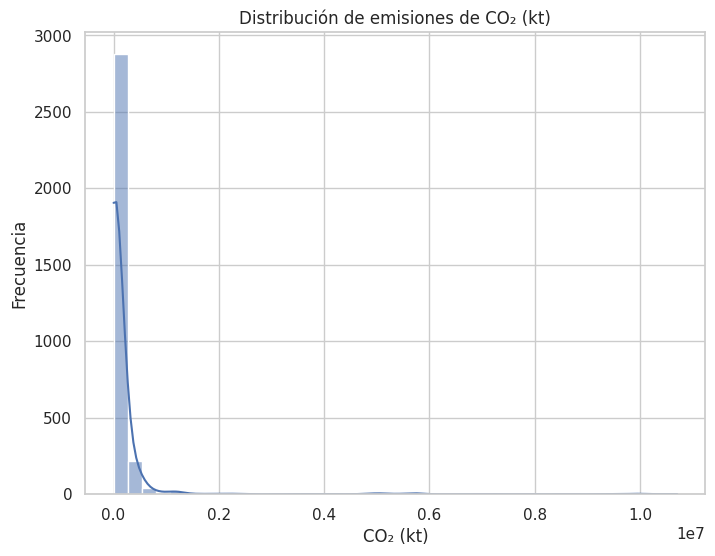

np.float64(9.337673452271902)

In [4]:
# Distribución de emisiones de CO₂

# sns.histplot dibuja un histograma de la variable especificada
# bins=40 controla el número de barras (cuanto más barras, mayor detalle)
# kde=True añade una curva de densidad suavizada encima del histograma
plt.figure(figsize=(8,6))
sns.histplot(df["Value_co2_emissions_kt_by_country"], bins=40, kde=True)

plt.title("Distribución de emisiones de CO₂ (kt)")
plt.xlabel("CO₂ (kt)")
plt.ylabel("Frecuencia")
plt.show()

# .skew() calcula el coeficiente de asimetría: positivo = cola a la derecha, negativo = cola a la izquierda
df["Value_co2_emissions_kt_by_country"].skew()

La distribución de emisiones de CO₂ presenta una asimetría positiva muy pronunciada (skew ≈ 9,34). Esto quiere decir que la mayoría de países tienen emisiones relativamente bajas, pero hay un grupo pequeño de grandes economías (China, EE.UU., India) con emisiones muy por encima de la media que estiran la cola derecha de la distribución.

### 5.2 Distribución del consumo energético per cápita

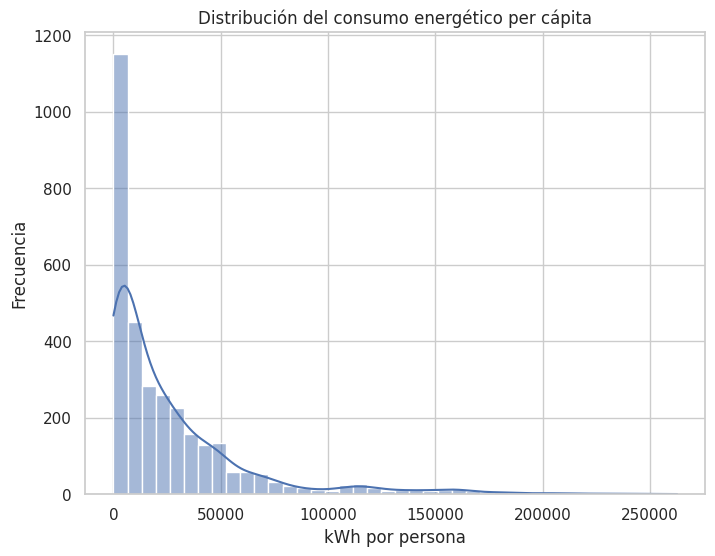

np.float64(2.5776325585123234)

In [5]:
# Distribución del consumo energético per cápita
# Mismo esquema que el histograma anterior, aplicado a la segunda variable objetivo

plt.figure(figsize=(8,6))
sns.histplot(df["Primary energy consumption per capita (kWh/person)"], bins=40, kde=True)

plt.title("Distribución del consumo energético per cápita")
plt.xlabel("kWh por persona")
plt.ylabel("Frecuencia")
plt.show()

df["Primary energy consumption per capita (kWh/person)"].skew()

El consumo energético per cápita también tiene asimetría positiva (skew ≈ 2,58), aunque menos extrema que en el caso de las emisiones. Esta nueva distribución refleja la gran diferencia en desarrollo entre los países: las economías con poco acceso a la energía tienen consumos muy bajos, mientras que las economías más industrializadas tienen consumos mucho más altos.

### 5.3 Distribución del PIB per cápita

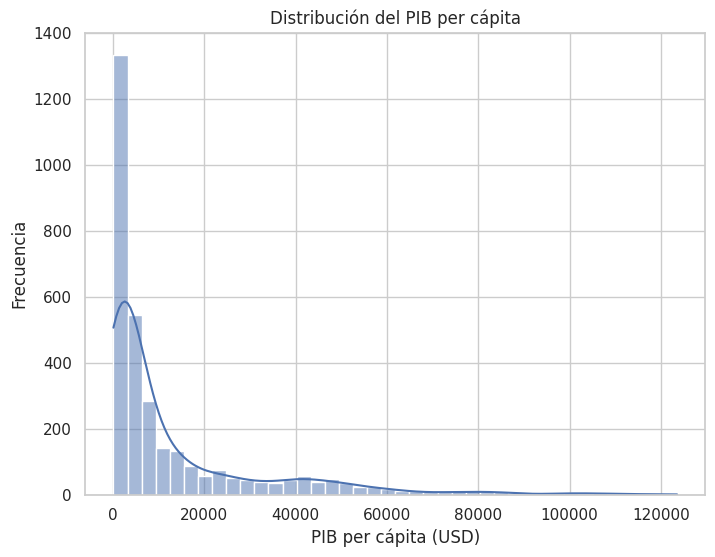

np.float64(2.355010641792001)

In [6]:
# Distribución del PIB per cápita

plt.figure(figsize=(8,6))
sns.histplot(df["gdp_per_capita"], bins=40, kde=True)

plt.title("Distribución del PIB per cápita")
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Frecuencia")
plt.show()

df["gdp_per_capita"].skew()

El PIB per cápita sigue el mismo patrón (skew ≈ 2,36), con la mayoría de países teniendo niveles de renta moderados o bajos, y un número reducido de economías muy desarrolladas que concentra los valores más altos. Esto es especialmente relevante para nuestro estudio porque el PIB per cápita será una de las variables explicativas más importantes en el consumo energético, como veremos después.

### Conclusión del análisis univariado

Las tres variables tienen distribuciones asimétricas con cola derecha, especialmente las emisiones de CO₂. Esto es un patrón esperable en datos macroeconómicos globales, pues la actividad económica y energética están muy concentradas en unas pocas grandes economías. Esta asimetría puede hacer que los errores de predicción tiendan a ser mayores en los países más grandes, cosa que habrá que tener en cuenta al interpretar las métricas de los modelos más adelante.

---
**Notas adicionales**

La asimetría (skewness) mide cuánto se desvía una distribución de la distribución normal (campana de Gauss). Un valor positivo alto indica que hay una cola larga hacia la derecha, es decir, valores extremos muy por encima de la media.

## 6. DETECCIÓN DE OUTLIERS

### 6.1 Boxplot de emisiones de CO₂

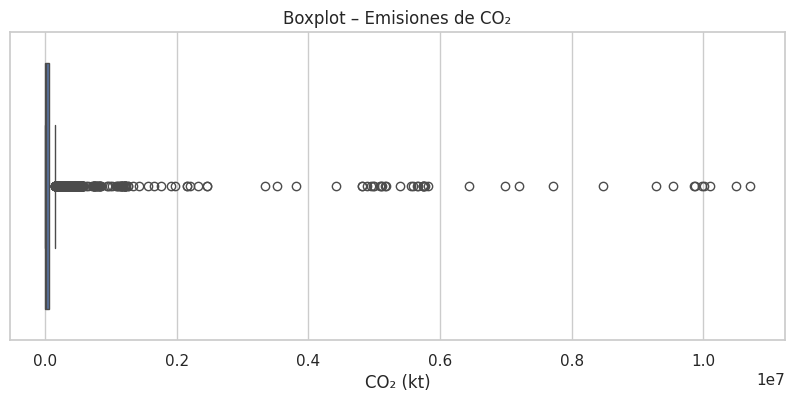

In [7]:
# Boxplot de emisiones de CO₂
# El boxplot muestra la mediana (línea central), el rango intercuartílico IQR (caja)
# y los valores extremos (puntos individuales fuera de los bigotes)
# Es más informativo que el histograma para detectar outliers

plt.figure(figsize=(10,4))
sns.boxplot(x=df["Value_co2_emissions_kt_by_country"])

plt.title("Boxplot – Emisiones de CO₂")
plt.xlabel("CO₂ (kt)")
plt.show()

El boxplot confirma la distribución asimétrica: hay una concentración de países con emisiones relativamente bajas y una cola muy larga hacia valores altos. Los puntos identificados como outliers según el criterio IQR corresponden principalmente a países como China, EE.UU., India y Rusia.

### 6.2 Boxplot de consumo energético per cápita

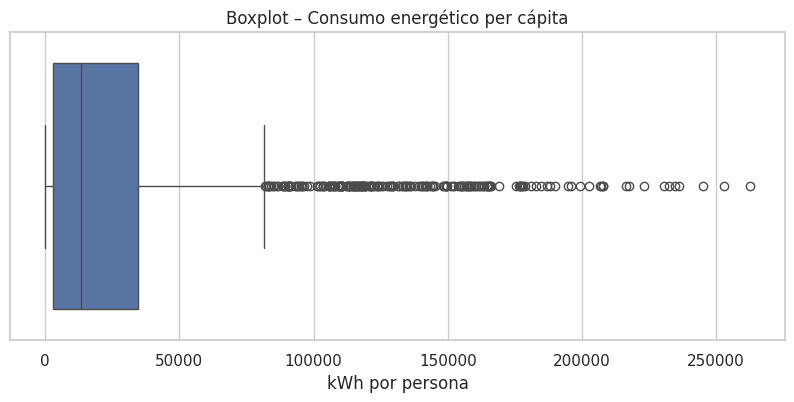

In [8]:
# Boxplot de consumo energético per cápita

plt.figure(figsize=(10,4))
sns.boxplot(x=df["Primary energy consumption per capita (kWh/person)"])

plt.title("Boxplot – Consumo energético per cápita")
plt.xlabel("kWh por persona")
plt.show()

El consumo energético per cápita también presenta outliers hacia valores altos, asociados a economías muy industrializadas o con características energéticas particulares, como países con un clima extremo que requieren mucha calefacción o refrigeración, o países con industrias muy pesadas.

### Conclusión del análisis de outliers

Se han identificado varios outliers en ambas variables, pero no se eliminan puesto que suponen valores reales correspondientes a las economías de mayor escala mundial.

---
**Notas adicionales**

En ciencia de datos, la decisión de eliminar o mantener outliers depende del contexto. Si fueran errores de medición, habría que eliminarlos. Pero cuando son valores reales de entidades que forman parte del fenómeno que estamos estudiando (como en nuestro caso, los países más grandes en un análisis global), los mantenemos en el dataset.

## 7. ANÁLISIS BIVARIADO Y MULTIVARIADO

En esta sección se estudian las relaciones entre variables. Se hará en tres pasos: primero un análisis de correlaciones para ver qué variables están asociadas con las variables objetivo, segundo una detección de redundancia para identificar si hay predictores que estén midiendo lo mismo, y finalmente un análisis mediante el factor de inflación de la varianza, VIF, para comprobar que no haya multicolinealidad entre los predictores.

### 7.1 Análisis de correlaciones

Se calculan las correlaciones entre todas las variables numéricas del dataset, prestando especial atención a aquellas con nuestras dos variables objetivo.

---
**Notas adicionales**

La correlación de Pearson mide la fuerza y dirección de la relación lineal entre dos variables, tomando valores entre -1 y +1. Un valor cercano a 1 indica correlación positiva fuerte (cuando una sube, la otra también), cercano a -1 indica correlación negativa fuerte, y cercano a 0 indica que no hay relación lineal. Es la técnica más directa para medir si dos variables se mueven juntas.

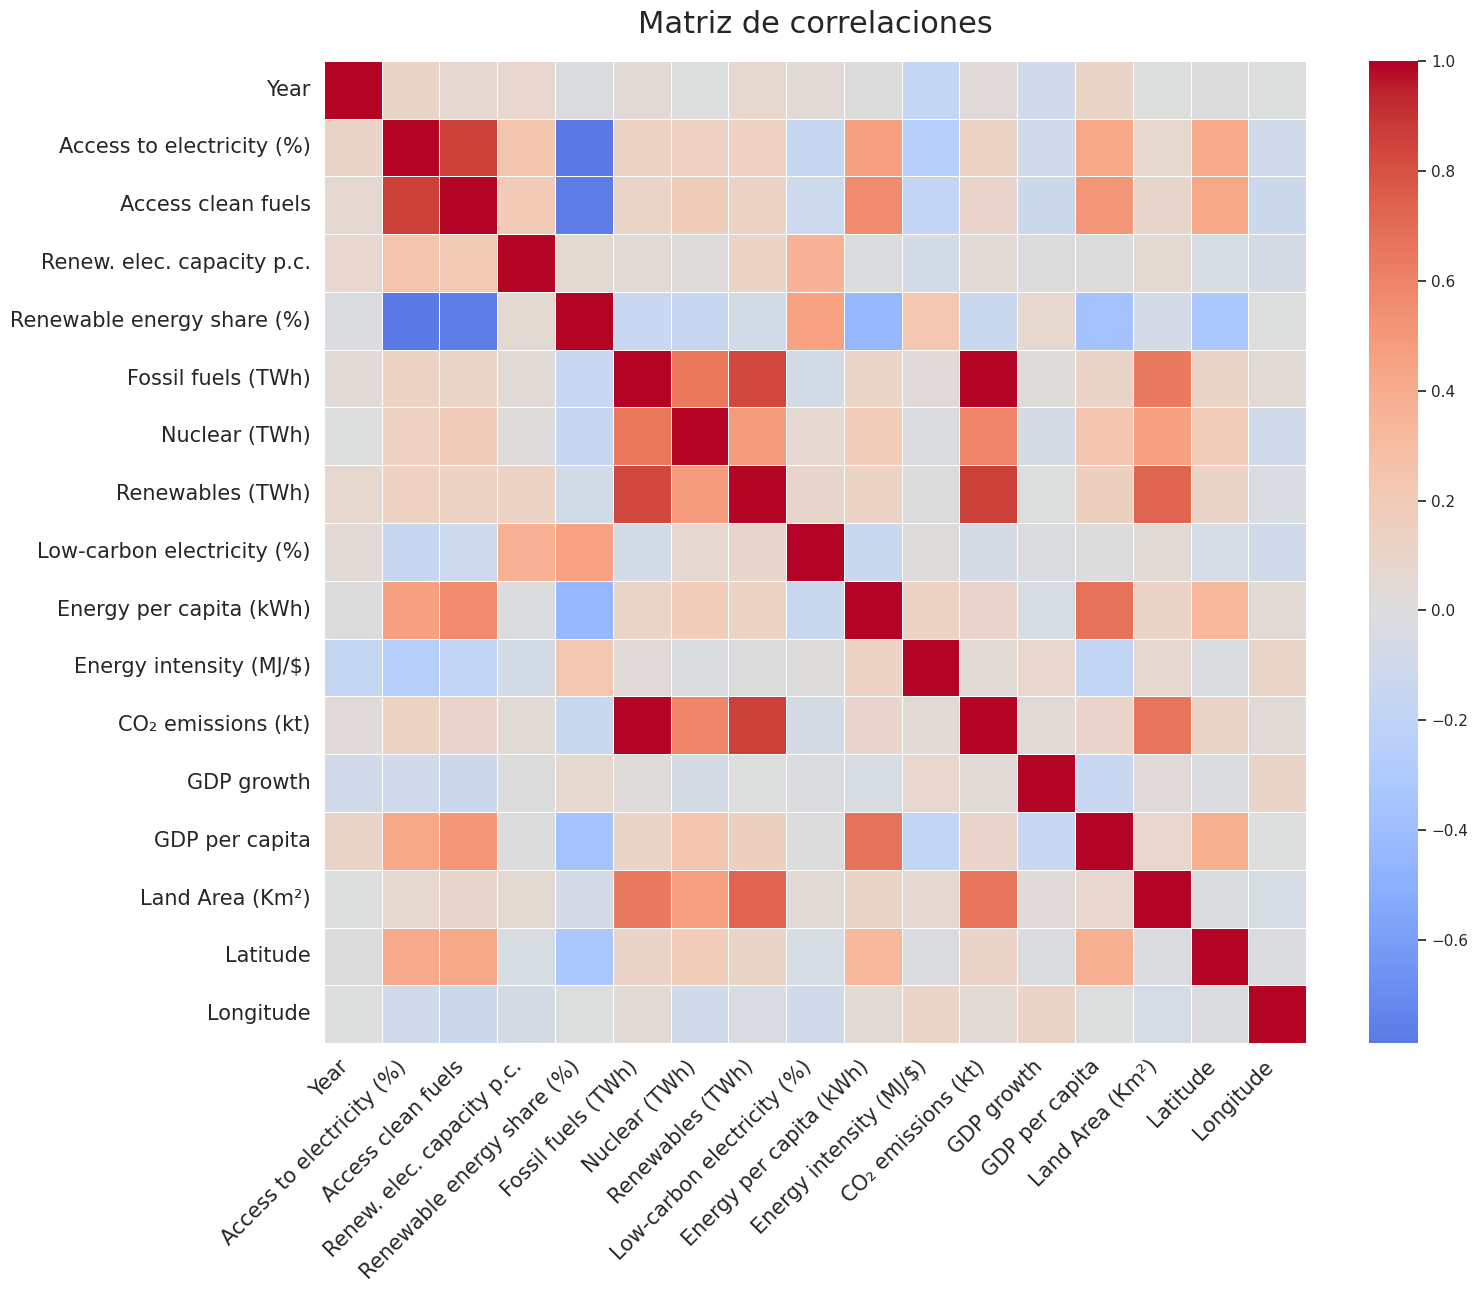

In [9]:
# Análisis de correlaciones

# Seleccionamos las columnas numéricas para calcular las correlaciones
numeric_df = df.select_dtypes(include=np.number)

# Renombramos las columnas SOLO para el heatmap, sin modificar el DataFrame original
# Esto mejora la legibilidad de la figura sin afectar al resto del código
rename_map = {
    "Access to electricity (% of population)": "Access to electricity (%)",
    "Access to clean fuels for cooking": "Access clean fuels",
    "Renewable-electricity-generating-capacity-per-capita": "Renew. elec. capacity p.c.",
    "Renewable energy share in the total final energy consumption (%)": "Renewable energy share (%)",
    "Electricity from fossil fuels (TWh)": "Fossil fuels (TWh)",
    "Electricity from nuclear (TWh)": "Nuclear (TWh)",
    "Electricity from renewables (TWh)": "Renewables (TWh)",
    "Low-carbon electricity (% electricity)": "Low-carbon electricity (%)",
    "Primary energy consumption per capita (kWh/person)": "Energy per capita (kWh)",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)": "Energy intensity (MJ/$)",
    "Value_co2_emissions_kt_by_country": "CO\u2082 emissions (kt)",
    "Land Area(Km2)": "Land Area (Km\u00b2)",
    "gdp_growth": "GDP growth",
    "gdp_per_capita": "GDP per capita",
}

# Calculamos la correlación y renombramos ejes
corr_matrix = numeric_df.corr()
corr_matrix = corr_matrix.rename(index=rename_map, columns=rename_map)

# Visualización con mapa de calor
# coolwarm: azul para correlaciones negativas, rojo para positivas, blanco para cero
# center=0 asegura que el blanco corresponda exactamente a correlación = 0
plt.figure(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Matriz de correlaciones", fontsize=22, pad=20)
plt.xticks(fontsize=15, rotation=45, ha="right")
plt.yticks(fontsize=15, rotation=0)
plt.tight_layout()
plt.show()


#### Correlación con emisiones de CO₂

In [10]:
# Correlación de todas las variables con las emisiones de CO₂
# .corr() calcula la correlación de cada variable con todas las demás
# Seleccionamos solo la columna del CO₂ y ordenamos de mayor a menor
corr_co2 = (
    numeric_df
    .corr()["Value_co2_emissions_kt_by_country"]   # columna con correlaciones vs CO₂
    .sort_values(ascending=False)                   # ordenar de mayor a menor correlación
)

print(corr_co2)

Value_co2_emissions_kt_by_country                                   1.000000
Electricity from fossil fuels (TWh)                                 0.989620
Electricity from renewables (TWh)                                   0.856162
Land Area(Km2)                                                      0.653732
Electricity from nuclear (TWh)                                      0.597852
Access to electricity (% of population)                             0.127409
Latitude                                                            0.115571
gdp_per_capita                                                      0.096837
Primary energy consumption per capita (kWh/person)                  0.095683
Access to clean fuels for cooking                                   0.095358
Renewable-electricity-generating-capacity-per-capita                0.039537
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         0.039478
Longitude                                                           0.036286

Las emisiones de CO₂ muestran una correlación de r ≈ 0,99 con la electricidad a partir de combustibles fósiles. Esto tiene sentido físicamente, la generación eléctrica con combustibles fósiles produce CO₂ de forma casi proporcional. También hay correlaciones relevantes con la generación renovable y nuclear, aunque estas seguramente responden principalmente a efecto de escala: los países grandes generan más electricidad (de todos los tipos) y también emiten más en términos absolutos.

Esta correlación tan alta con los combustibles fósiles supone una señal de alerta para el modelado, porque incluir la variable de generación fósil como predictor de CO₂ va a ser casi como predecir una variable con ella misma. Lo abordaremos con más detalle en la sección 9.14.

#### Correlación con consumo energético per cápita

In [11]:
# Correlación de todas las variables con el consumo energético per cápita
# Mismo procedimiento que para CO₂:

corr_energy = (
    numeric_df
    .corr()["Primary energy consumption per capita (kWh/person)"]
    .sort_values(ascending=False)
)

print(corr_energy)

Primary energy consumption per capita (kWh/person)                  1.000000
gdp_per_capita                                                      0.675754
Access to clean fuels for cooking                                   0.563864
Access to electricity (% of population)                             0.463872
Latitude                                                            0.335772
Electricity from nuclear (TWh)                                      0.178512
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         0.133908
Electricity from renewables (TWh)                                   0.123054
Land Area(Km2)                                                      0.119128
Electricity from fossil fuels (TWh)                                 0.106438
Value_co2_emissions_kt_by_country                                   0.095683
Longitude                                                           0.037738
Year                                                                0.005373

El consumo energético per cápita tiene las correlaciones más altas con el PIB per cápita (r ≈ 0,68), el acceso a combustibles limpios para cocinar (r ≈ 0,56) y el acceso a electricidad (r ≈ 0,46). Estas variables reflejan el nivel de desarrollo económico de los países.

La correlación negativa con la proporción de energía renovable (r ≈ −0,44) puede resultar contraintuitiva, pero puede tener una explicación estructural: los países con menor renta tienden a tener una mayor proporción de renovables en su mix energético (principalmente biomasa tradicional y pequeña hidroeléctrica), pero con un consumo total por habitante muy bajo. Esta relación no implica por tanto que las renovables reduzcan el consumo, sino más bien refleja diferencias estructurales entre economías desarrolladas y en desarrollo.

### 7.2 Detección de redundancia entre variables

Se identifican pares de variables con correlación absoluta superior a 0.9 para detectar posibles redundancias entre los predictores.

---
**Notas adicionales**

Si dos predictores están muy correlacionados entre sí (por ejemplo, r > 0.9), incluir los dos en el modelo nos aporta poca información adicional pero puede generar inestabilidad en los coeficientes. Esta es la multicolinealidad. En este paso hacemos una detección preliminar antes del análisis VIF más formal.

In [12]:
# Detección de redundancia entre variables (correlación > 0.9)

# Calculamos la matriz de correlaciones en valor absoluto
corr_matrix = numeric_df.corr().abs()

# Extraemos solo el triángulo superior de la matriz para no contar cada par dos veces
# np.triu crea una matriz de unos en el triángulo superior, k=1 excluye la diagonal
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identificamos las variables que tienen alguna correlación > 0.9 con otra variable
high_corr_vars = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.9)
]

print("Variables con correlación > 0.9 con alguna otra variable:")
print(high_corr_vars)

Variables con correlación > 0.9 con alguna otra variable:
['Value_co2_emissions_kt_by_country']


Solo se detecta una relación por encima de 0.9 entre las propias variables explicativas: la que ya conocíamos entre CO₂ y generación fósil. En principio no hay más redundancias problemáticas entre los predictores.

### 7.3 Selección inicial de variables por análisis de correlaciones

Con las columnas que pasaron la limpieza (en la sección 4), ya se han calculado en la sección 7.1 las correlaciones con nuestras dos variables objetivo. A partir de esos resultados, y antes de calcular el VIF, vamos a hacer un primer filtrado descartando las variables que presentan correlaciones bajas con ambos objetivos y para las que tampoco tenemos una clara justificación teórica para su inclusión:

- `Latitude` y `Longitude` — Correlaciones muy bajas con CO₂ (r ≈ 0,12 y r ≈ 0,04) y con el consumo per cápita (r ≈ 0,34 y r ≈ 0,04). La latitud tiene cierta relación con el consumo a través del clima (países más fríos consumen más energía para calefacción), pero es una relación un poco ruidosa comparada con las variables económicas disponibles como el PIB per cápita, que ya captura gran parte de esa variabilidad. Longitud no tiene ninguna interpretación causal relevante. Descartamos ambas columnas.

- `Renewable-electricity-generating-capacity-per-capita` — Correlación casi nula con ambas variables objetivo (r ≈ 0,04 con CO₂, r ≈ −0,01 con consumo). Mide la capacidad instalada por habitante, pero no la generación real ni el consumo, así que su poder explicativo es muy limitado frente a las demás variables. La descartamos.

- `Density` — Correlación prácticamente nula con ambas variables objetivo (r ≈ 0,01 en ambos casos). No aporta información adicional a la que ya dan el PIB per cápita y la superficie del país. Se descarta.

- `Access to clean fuels for cooking` — Quizá es el caso menos evidente, ya que tiene correlación con el consumo per cápita (r ≈ 0,56). Sin embargo, mide un concepto muy similar a `Access to electricity (% of population)` (r ≈ 0,46 con consumo), que ya entra en el modelo de energía. Incluir las dos introduciría seguramente redundancia y sin mejorar la capacidad explicativa, y `Access to electricity` tiene mejor cobertura de datos. Se descarta por tanto `Access to clean fuels for cooking`.

Tras este estudio, el conjunto de variables candidatas para cada modelo queda listo para el análisis de multicolinealidad.

### 7.4 Selección diferenciada de variables por modelo

Tras descartar las variables con correlaciones bajas o redundantes, las variables restantes se asignan a cada modelo en función de su relevancia para la variable objetivo correspondiente.

#### Variables para el Modelo A (emisiones de CO₂)

Las emisiones de CO₂ son una magnitud absoluta (kt totales por país), por lo que las variables que más correlacionan con ellas son las de generación eléctrica, que capturan el tamaño y la composición del sistema energético: la generación fósil (r ≈ 0,99), la renovable (r ≈ 0,86) y la nuclear (r ≈ 0,60). Se añaden la cuota renovable (r ≈ −0,13) y el porcentaje de electricidad baja en carbono (r ≈ −0,05), que aportan información sobre la estructura del mix energético; la intensidad energética (r ≈ 0,04), relevante dentro de la identidad de Kaya; y `Year` (r ≈ 0,02), que captura la tendencia temporal.

Se excluyen las variables económicas (`gdp_per_capita`, r ≈ 0,10; `gdp_growth`, r ≈ 0,03) y de acceso (`Access to electricity`, r ≈ 0,13), cuyas correlaciones con las emisiones totales son muy bajas. Esto se explica porque las emisiones totales dependen del tamaño del sistema energético, no del nivel de renta per cápita. `Land Area` (r ≈ 0,65) se excluye por ser un proxy del tamaño del país ya capturado por las variables de generación.

La correlación casi perfecta entre generación fósil y CO₂ (r ≈ 0,99) invita a explorar un modelo con y otro sin dicha variable, para evaluar si el modelo aprende relaciones estructurales genuinas o simplemente reproduce una relación física casi directa.

#### Variables para el Modelo B (consumo energético per cápita)

Al tratarse de una magnitud per cápita, las variables económicas y de acceso cobran protagonismo. El PIB per cápita es el predictor con mayor correlación (r ≈ 0,68), seguido del acceso a electricidad (r ≈ 0,46). La cuota renovable presenta una correlación negativa notable (r ≈ −0,44): los países con mayor proporción de renovables tienden a tener consumos per cápita más moderados. Se incluye `gdp_growth` (r ≈ −0,04) porque aporta información sobre la dinámica de crecimiento que complementa al PIB per cápita.

Las variables de generación se mantienen (r ≈ 0,11–0,18) porque capturan la estructura del sistema energético. La intensidad energética (r ≈ 0,13) refleja la eficiencia del sistema productivo, y `Land Area` (r ≈ 0,12) se incluye como indicador de escala territorial. `Year` se incluye inicialmente para verificar su comportamiento en el análisis VIF.


### 7.5 Verificación de multicolinealidad (VIF)


#### 7.5.1 Modelo de emisiones de CO₂


In [13]:
# Análisis VIF – Modelo de emisiones de CO₂

# variance_inflation_factor de statsmodels calcula el VIF de cada variable
# dado el conjunto completo de predictores

# Lista de variables predictoras en el modelo de CO₂
features_co2 = [
    "Year",
    "Electricity from fossil fuels (TWh)",
    "Electricity from nuclear (TWh)",
    "Electricity from renewables (TWh)",
    "Renewable energy share in the total final energy consumption (%)",
    "Low-carbon electricity (% electricity)",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)"
]

# Creamos un DataFrame solo con esas variables para calcular el VIF
X_co2_vif = df[features_co2]

# Calculamos el VIF para cada variable en su posición i
# variance_inflation_factor recibe la matriz completa y el índice de la columna a evaluar
vif_data_co2 = pd.DataFrame()
vif_data_co2["Feature"] = X_co2_vif.columns
vif_data_co2["VIF"] = [
    variance_inflation_factor(X_co2_vif.values, i)
    for i in range(X_co2_vif.shape[1])
]

# Mostramos ordenado de mayor a menor VIF
print(vif_data_co2.sort_values("VIF", ascending=False))

                                             Feature       VIF
1                Electricity from fossil fuels (TWh)  5.310740
0                                               Year  4.696138
3                  Electricity from renewables (TWh)  4.041702
6  Energy intensity level of primary energy (MJ/$...  3.553660
5             Low-carbon electricity (% electricity)  3.254984
4  Renewable energy share in the total final ener...  3.209941
2                     Electricity from nuclear (TWh)  1.935552


Todos los VIF están por debajo de 10, lo que indica que no hay problemas graves de multicolinealidad. La variable de generación fósil tiene el VIF más alto (≈ 5,31), pero en un nivel aceptable para continuar.

#### 7.5.2 Modelo de consumo energético per cápita


In [14]:
# Análisis VIF – Modelo de consumo energético per cápita (segunda iteración - sin 'Year')

features_energy_refined = [
    "gdp_per_capita",
    "gdp_growth",
    "Electricity from fossil fuels (TWh)",
    "Electricity from nuclear (TWh)",
    "Electricity from renewables (TWh)",
    "Renewable energy share in the total final energy consumption (%)",
    "Low-carbon electricity (% electricity)",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)",
    "Access to electricity (% of population)",
    "Land Area(Km2)"
]

X_energy_refined = df[features_energy_refined]

# Mismo cálculo de VIF que para el modelo de CO₂
vif_data_energy = pd.DataFrame()
vif_data_energy["Feature"] = X_energy_refined.columns
vif_data_energy["VIF"] = [
    variance_inflation_factor(X_energy_refined.values, i)
    for i in range(X_energy_refined.shape[1])
]

print(vif_data_energy.sort_values("VIF", ascending=False))

                                             Feature       VIF
2                Electricity from fossil fuels (TWh)  5.406974
4                  Electricity from renewables (TWh)  5.259425
8            Access to electricity (% of population)  3.937498
5  Renewable energy share in the total final ener...  3.575729
6             Low-carbon electricity (% electricity)  3.567788
7  Energy intensity level of primary energy (MJ/$...  3.342892
9                                     Land Area(Km2)  2.543914
3                     Electricity from nuclear (TWh)  2.108094
0                                     gdp_per_capita  1.920524
1                                         gdp_growth  1.569986


Tras eliminar la variable de Year, todos los VIF bajan drásticamente, con lo que la multicolinealidad pasa a considerarse aceptable y se puede proceder con el modelado.

### 7.6 Resumen del proceso de selección de variables

El proceso de selección de variables se ha desarrollado en cinco pasos:

1. **Limpieza (sección 4):** se eliminaron `Financial flows to developing countries` y `Renewables (% equivalent primary energy)` por superar el umbral del 40% de valores faltantes.

2. **Descarte por correlación baja (sección 7.3):** se excluyeron `Latitude`, `Longitude`, `Renewable-electricity-generating-capacity-per-capita`, `Density` y `Access to clean fuels for cooking`.

3. **Asignación diferenciada por modelo (sección 7.4):** las variables económicas y de acceso se incluyen solo en el Modelo B; se excluyen del Modelo A por baja correlación con emisiones totales.

4. **Verificación VIF (sección 7.5):** se comprueba que no haya multicolinealidad excesiva. En el Modelo A todos los VIF son aceptables. En el Modelo B, `Year` presenta VIF ≈ 40 (colinealidad con `gdp_per_capita`), por lo que se excluye.

5. **Variables finales:**
   - Modelo A – CO₂: `Year`, `Electricity from fossil fuels (TWh)`*, `Electricity from nuclear (TWh)`, `Electricity from renewables (TWh)`, `Renewable energy share (%)`, `Low-carbon electricity (%)`, `Energy intensity (MJ/$GDP)` — *excluida en el modelo revisado.
   - Modelo B – Energía per cápita: `gdp_per_capita`, `gdp_growth`, `Electricity from fossil fuels (TWh)`, `Electricity from nuclear (TWh)`, `Electricity from renewables (TWh)`, `Renewable energy share (%)`, `Low-carbon electricity (%)`, `Energy intensity (MJ/$GDP)`, `Access to electricity (%)`, `Land Area (Km²)`.


Como alternativa al proceso de selección de variables que hemos llevado a cabo, podría haberse aplicado el Análisis de Componentes Principales (PCA) para reducir la dimensionalidad del dataset.

Sin embargo, se ha optado por no utilizarlo por dos razones principales. En primer lugar, el número de variables del dataset es reducido (21 columnas originales, de las cuales menos de la mitad entran en cada modelo), por lo que la reducción de dimensionalidad no sería necesaria. En segundo lugar, y más importante, PCA transforma las variables originales en combinaciones lineales abstractas que pierden su interpretación directa, lo que dificultaría estudiar qué factores determinan las emisiones de carbono o el consumo energético.

Dado que uno de los objetivos del trabajo es precisamente el de identificar determinantes estructurales de ambos fenómenos, se ha preferido mantener las variables originales con su significado económico y energético intacto.

## 8. ANÁLISIS TEMPORAL GLOBAL

Esta sección analiza cómo han evolucionado las dos variables principales a lo largo del tiempo entre 2000 y 2019. También se añade una referencia en 2015 (año del Acuerdo de París) para ver si hay algún cambio visible en las tendencias después de ese momento.

### 8.1 Evolución global de emisiones de CO₂

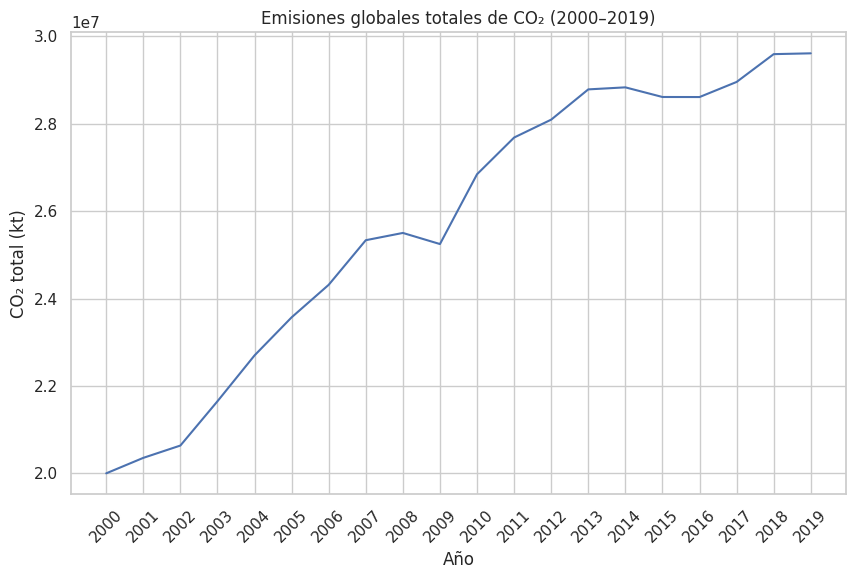

In [15]:
# Evolución temporal de las emisiones globales de CO₂

# Agrupamos por año y sumamos las emisiones de todos los países
# Esto nos da las emisiones totales mundiales para cada año
global_co2 = (
    df[df["Year"] < 2020]                               # solo años hasta 2019
    .groupby("Year", as_index=False)                    # agrupamos por año
    ["Value_co2_emissions_kt_by_country"]
    .sum()                                               # sumamos las emisiones de todos los países
)

plt.figure(figsize=(10,6))
plt.plot(global_co2["Year"], global_co2["Value_co2_emissions_kt_by_country"])

plt.title("Emisiones globales totales de CO₂ (2000–2019)")
plt.xlabel("Año")
plt.ylabel("CO₂ total (kt)")
plt.xticks(global_co2["Year"], rotation=45)   # un tick por año, rotados 45° para que quepan
plt.grid(True)
plt.show()

Las emisiones globales de CO₂ muestran una tendencia creciente sostenida durante el periodo analizado. Hay pequeñas fluctuaciones interanuales pero la tendencia de fondo es claramente al alza, impulsada principalmente por el crecimiento económico de economías emergentes, sobre todo en Asia.

### 8.2 Evolución global de la proporción de energías renovables

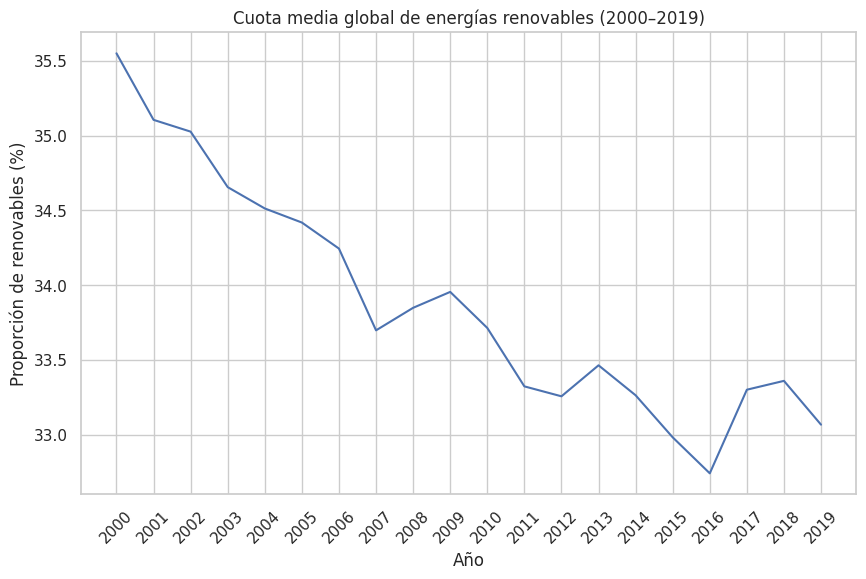

In [16]:
# Evolución temporal de la proporción media de energías renovables

# Agrupamos por año y calculamos la media
global_renew = (
    df[df["Year"] < 2020]
    .groupby("Year", as_index=False)
    ["Renewable energy share in the total final energy consumption (%)"]
    .mean()   # media de todos los países ese año
)

plt.figure(figsize=(10,6))
plt.plot(
    global_renew["Year"],
    global_renew["Renewable energy share in the total final energy consumption (%)"]
)

plt.title("Cuota media global de energías renovables (2000–2019)")
plt.xlabel("Año")
plt.ylabel("Proporción de renovables (%)")
plt.xticks(global_renew["Year"], rotation=45)
plt.grid(True)
plt.show()

La proporción media global de energías renovables en el consumo final no muestra un cambio abrupto en el periodo estudiado. Tenemos variaciones moderadas de año en año, lo que confirma que la transición energética es un proceso gradual que se desarrolla a lo largo de décadas, y no de un año para otro.

### 8.3 Referencia temporal: Acuerdo de París (2015)

El Acuerdo de París, adoptado en 2015 en el marco de la Convención Marco de las Naciones Unidas sobre el Cambio Climático, es un tratado internacional cuyo objetivo principal es limitar el calentamiento global a 2 °C respecto a niveles preindustriales, e idealmente a 1,5 °C.

Para lograrlo, los países firmantes se comprometen a:

* Reducir sus emisiones de gases de efecto invernadero, especialmente de CO₂

* Transitar hacia sistemas energéticos más sostenibles

* Revisar periódicamente sus objetivos climáticos (NDCs)

Este estudio se alinea con dichos objetivos, ya que analiza las emisiones de CO₂ y su relación con variables energéticas, permitiendo identificar factores clave en la transición hacia un sistema energético más sostenible.

Así pues, vamos a añadir una línea vertical en 2015 en los gráficos para estudiar visualmente si hay algún cambio en las tendencias que pudiera estar ligado a la firma dicho acuerdo.

#### Emisiones globales con referencia a 2015

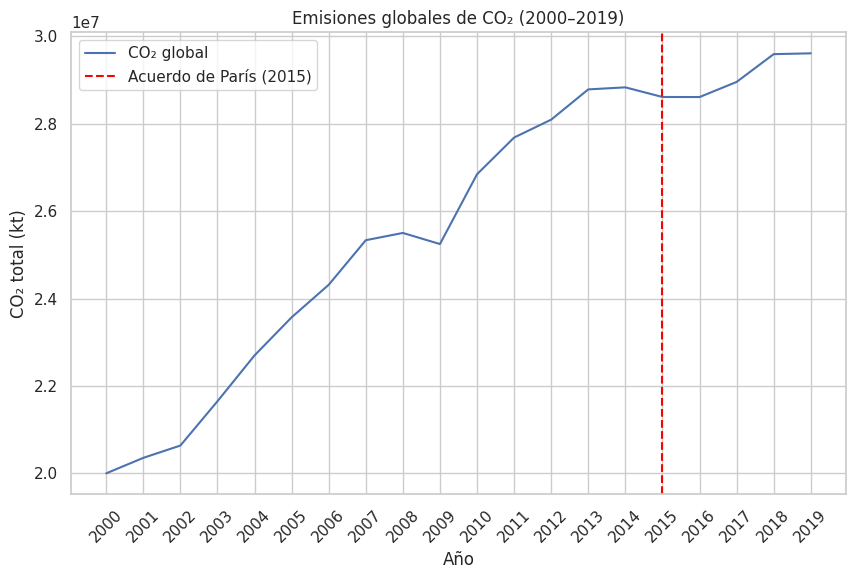

In [17]:
# Emisiones globales con referencia al Acuerdo de París (2015)

plt.figure(figsize=(10,6))
plt.plot(global_co2["Year"], global_co2["Value_co2_emissions_kt_by_country"], label="CO₂ global")

# plt.axvline dibuja una línea vertical en x=2015 para marcar el año del Acuerdo de París
plt.axvline(x=2015, color="red", linestyle="--", label="Acuerdo de París (2015)")

plt.title("Emisiones globales de CO₂ (2000–2019)")
plt.xlabel("Año")
plt.ylabel("CO₂ total (kt)")
plt.legend()
plt.xticks(global_co2["Year"], rotation=45)
plt.grid(True)
plt.show()

#### Proporción renovable con referencia a 2015

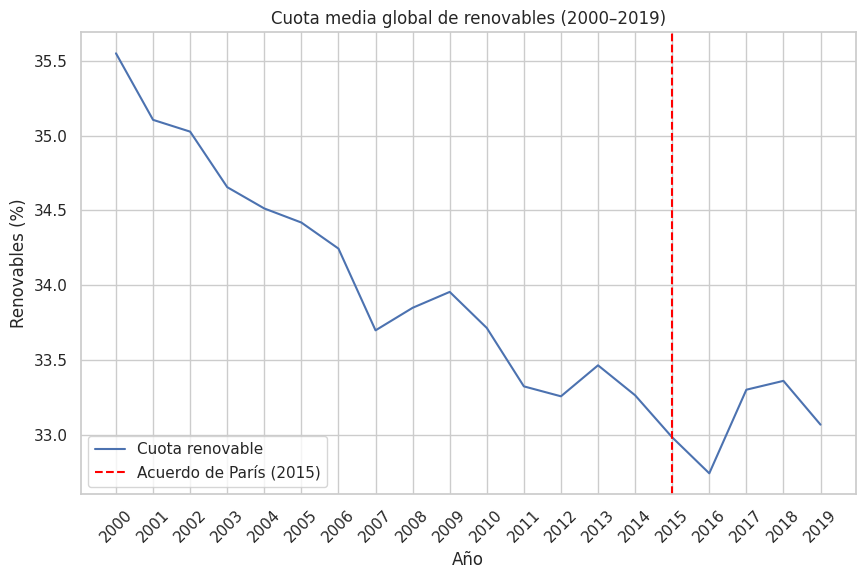

In [18]:
# Cuota renovable con referencia al Acuerdo de París (2015)

plt.figure(figsize=(10,6))
plt.plot(
    global_renew["Year"],
    global_renew["Renewable energy share in the total final energy consumption (%)"],
    label="Cuota renovable"
)

plt.axvline(x=2015, color="red", linestyle="--", label="Acuerdo de París (2015)")

plt.title("Cuota media global de renovables (2000–2019)")
plt.xlabel("Año")
plt.ylabel("Renovables (%)")
plt.legend()
plt.xticks(global_renew["Year"], rotation=45)
plt.grid(True)
plt.show()

### 8.4 Comparación antes y después de 2015

In [19]:
# Comparación estadística antes y después de 2015

# Calculamos la media de emisiones en los dos periodos para ver si hay cambio
co2_before = global_co2[global_co2["Year"] < 2015]["Value_co2_emissions_kt_by_country"].mean()
co2_after  = global_co2[global_co2["Year"] >= 2015]["Value_co2_emissions_kt_by_country"].mean()

print("Promedio CO₂ antes de 2015:", round(co2_before, 0), "kt")
print("Promedio CO₂ después de 2015:", round(co2_after, 0), "kt")

# Lo mismo para la cuota de renovables
renew_before = global_renew[global_renew["Year"] < 2015]     ["Renewable energy share in the total final energy consumption (%)"].mean()
renew_after = global_renew[global_renew["Year"] >= 2015]     ["Renewable energy share in the total final energy consumption (%)"].mean()

print("\nCuota renovable antes de 2015:", round(renew_before, 2), "%")
print("Cuota renovable después de 2015:", round(renew_after, 2), "%")

Promedio CO₂ antes de 2015: 24636517.0 kt
Promedio CO₂ después de 2015: 29076423.0 kt

Cuota renovable antes de 2015: 34.14 %
Cuota renovable después de 2015: 33.09 %


Las emisiones globales siguen subiendo después de 2015 sin ninguna ruptura inmediata. Además, la proporción de renovables tampoco muestra cambios abruptos.

Esto es coherente con la naturaleza de las transiciones energéticas: los acuerdos políticos pueden marcar una dirección, pero los cambios reales en la infraestructura energética tardan décadas en materializarse.

### Conclusión del análisis temporal

La evolución del sistema energético global está dominada por factores estructurales de largo plazo (crecimiento económico, inversión en infraestructura, dependencia tecnológica de los combustibles fósiles) más que por cambios políticos puntuales. Este resultado refuerza el enfoque del modelado: tiene más sentido usar variables estructurales que limitarnos a estudiar las tendencias temporales sin más.

### Conclusiones del EDA

Antes de pasar al modelado, recordamos algunos puntos claves del EDA:

1. Las emisiones de CO₂ tienen una relación casi perfecta con la generación fósil, lo que sugiere que el modelo será muy preciso si incluimos esa variable pero que eso puede ser metodológicamente problemático.
2. El consumo per cápita depende principalmente del nivel de desarrollo económico, aunque presenta mayor complejidad que las emisiones de carbono.
3. No hay multicolinealidad severa entre los predictores seleccionados, salvo el caso de Year en el modelo de energía que ya se ha resuelto.
4. Hay asimetría y outliers en ambas variables objetivo, que se mantienen en el análisis.

## 9. MODELADO PREDICTIVO – MODELO A: EMISIONES DE CO₂

### 9.1 Planteamiento

El primer modelo tiene como objetivo predecir las emisiones totales de CO₂ por país y año (en kt).

Se prueban tres modelos distintos: Regresión Lineal como base fácilmente interpretable, Regresión de Ridge para estudiar si la regularización mejora el resultado, y Random Forest como contraste no lineal.

Como ya se comentó, para la división de datos haremos un entrenamiento con años 2000–2015 y test con 2016–2019.

### 9.2 Preparación de datos


train_df y test_df se construyen filtrando el dataset por año. Esto es lo que hace la división temporal: en lugar de usar sklearn's train_test_split (que reparte aleatoriamente), partimos manualmente por fecha. El conjunto de entrenamiento tiene todo hasta 2015 inclusive y el de test tiene 2016–2019.

A continuación se aplica StandardScaler para estandarizar las variables. Esto convierte cada variable para que tenga media 0 y desviación típica 1, de modo que todas las variables están en la misma escala antes de aplicar cualquier modelo. Va a ser especialmente importante para la Regresión de Ridge, cuya penalización L2 actúa sobre la magnitud de los coeficientes: sin estandarizar, variables con rangos de valores muy distintos recibirían una penalización desigual, afectando al normal funcionamiento del modelo.

El scaler se ajusta con los datos de entrenamiento (aprende su media y desviación típica) y esa misma transformación se aplica al test directamente sin reajustar nada Así, cuando llegan los datos nuevos, se transforman con los parámetros aprendidos durante el entrenamiento, evitando de nuevo el data leakage en el test.

In [20]:
# Preparación de datos – Modelo de emisiones de CO₂

# Lista de variables explicativas seleccionadas en el análisis exploratorio
features_co2_final = [
    "Year",
    "Electricity from fossil fuels (TWh)",
    "Electricity from nuclear (TWh)",
    "Electricity from renewables (TWh)",
    "Renewable energy share in the total final energy consumption (%)",
    "Low-carbon electricity (% electricity)",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)"
]

# Variable que queremos predecir
target_co2 = "Value_co2_emissions_kt_by_country"

# División temporal: train hasta 2015 inclusive, test 2016–2019
train_df = df[df["Year"] <= 2015]
test_df  = df[df["Year"] > 2015]

# Separamos predictores (X) y variable objetivo (y) para cada conjunto
X_train_co2 = train_df[features_co2_final]
y_train_co2 = train_df[target_co2]

X_test_co2 = test_df[features_co2_final]
y_test_co2 = test_df[target_co2]

# Estandarización de las variables explicativas (StandardScaler)
# El scaler se ajusta solo con los datos de entrenamiento (.fit_transform) y se
# aplica sin reajustar al conjunto de test (.transform), para evitar cualquier
# fuga de información del test al entrenamiento.
scaler_co2 = StandardScaler()
X_train_co2_scaled = scaler_co2.fit_transform(X_train_co2)   # ajusta y transforma el train
X_test_co2_scaled  = scaler_co2.transform(X_test_co2)        # solo transforma el test

print("Train shape:", X_train_co2_scaled.shape)
print("Test shape:", X_test_co2_scaled.shape)

Train shape: (2581, 7)
Test shape: (640, 7)


### 9.3 Regresión lineal múltiple


La regresión lineal múltiple estima los coeficientes que minimizan la suma de errores cuadráticos entre los valores predichos y los reales. Es el modelo más básico e interpretable y se suele usar como punto de partida para comparar con los modelos más complejos.

In [21]:
# Regresión lineal – Modelo CO₂

# .fit() ajusta los coeficientes minimizando la suma de errores cuadráticos
linreg_co2 = LinearRegression()
linreg_co2.fit(X_train_co2_scaled, y_train_co2)

# .predict() aplica el modelo entrenado a los datos de test escalados
y_pred_co2 = linreg_co2.predict(X_test_co2_scaled)

# Calculamos las métricas comparando predicciones con valores reales del test
r2_co2   = r2_score(y_test_co2, y_pred_co2)
mae_co2  = mean_absolute_error(y_test_co2, y_pred_co2)
rmse_co2 = np.sqrt(mean_squared_error(y_test_co2, y_pred_co2))

print("Resultados – Modelo CO₂ (Regresión Lineal)")
print("R²:  ", round(r2_co2, 4))
print("MAE: ", round(mae_co2, 0), "kt")
print("RMSE:", round(rmse_co2, 0), "kt")

Resultados – Modelo CO₂ (Regresión Lineal)
R²:   0.9748
MAE:  49746.0 kt
RMSE: 145583.0 kt


#### 9.4 Resultados

El modelo explica el 97,5% de la variabilidad de las emisiones en el test. Es un resultado muy alto, consecuencia directa de incluir la generación fósil como predictor (recordemos que tiene correlación r ≈ 0,99 con el objetivo).

---
**Notas adicionales**

R² mide la proporción de la variabilidad de la variable objetivo que explica el modelo. Un R² de 0,97 significa que el 97% de las diferencias en emisiones entre países y años queda explicado por las variables del modelo. MAE (Mean Absolute Error) es el error medio en las mismas unidades que la variable objetivo, más fácil de interpretar. RMSE (Root Mean Squared Error) penaliza más los errores grandes, lo que lo hace más sensible a los outliers.

#### 9.5 Interpretación de coeficientes

In [22]:
# Coeficientes de la regresión lineal para el modelo de CO₂

# Los coeficientes se interpretan sobre las variables estandarizadas:
# cuántas unidades cambia el CO₂ predicho cuando esa variable
# sube en una desviación típica, manteniendo el resto constante
coef_df_co2 = pd.DataFrame({
    "Feature": features_co2_final,
    "Coefficient": linreg_co2.coef_
})

print(coef_df_co2)

# El intercept es el valor predicho cuando todos los predictores son cero
print("Intercept:", linreg_co2.intercept_)

                                             Feature    Coefficient
0                                               Year   -8563.236965
1                Electricity from fossil fuels (TWh)  704079.969218
2                     Electricity from nuclear (TWh)  -59330.688104
3                  Electricity from renewables (TWh)   73408.477431
4  Renewable energy share in the total final ener...   -4914.686421
5             Low-carbon electricity (% electricity)    7892.315857
6  Energy intensity level of primary energy (MJ/$...    8998.424474
Intercept: 154265.67448948405


Los coeficientes indican el cambio estimado en las emisiones de CO₂ (en kt). Al estar estandarizadas las variables, los coeficientes son directamente comparables entre sí en cuanto a magnitud relativa:

* Electricidad fósil tiene con diferencia el coeficiente más alto (≈ +704.000 kt por σ), lo que refleja la relación casi directa entre generación fósil y emisiones. Un aumento de una desviación típica en esta variable implica un incremento masivo en las emisiones predichas.
* Electricidad renovable tiene coeficiente positivo (≈ +73.000 kt por σ), lo que refleja el efecto de escala: los países que generan más renovables son también los que tienen sistemas energéticos más grandes en general.
* Electricidad nuclear tiene coeficiente negativo (≈ −59.000 kt por σ), coherente con su papel de sustitución de fuentes fósiles.
* Intensidad energética tiene coeficiente positivo (≈ +9.000 kt por σ): mayor ineficiencia energética de la economía implica más emisiones.

---
**Notas adicionales**

Los coeficientes de la regresión lineal son coeficientes parciales que miden el efecto de cada variable manteniendo el resto constante. En la práctica, con datos observacionales como estos, se deben interpretar con cautela porque pueden estar capturando efectos confundidos entre variables correlacionadas.

Al estandarizar las variables, la interpretación de los coeficientes cambia respecto a lo que sería un modelo sin escalar:

* Sin estandarización, cada coeficiente indica el cambio en las emisiones de CO₂ por cada unidad adicional de la variable (por ejemplo, "cuántos kt de CO₂ tendremos por cada TWh adicional de generación fósil"), lo que resulta muy intuitivo pero tiene un problema: no puedes comparar directamente los coeficientes entre sí, porque las variables están medidas en escalas completamente distintas (TWh, porcentajes, índices de intensidad energética, etc.).

* Con estandarización, cada coeficiente indica el cambio en las emisiones cuando esa variable aumenta en una desviación típica, que es una unidad comparable entre todas las variables. Esto permite leer los coeficientes como una medida de influencia relativa: si el coeficiente de generación fósil es aproximadamente 10 veces mayor que el de electricidad renovable, se puede afirmar que una variación típica en generación fósil tiene un impacto sobre las emisiones unas 10 veces mayor que una variación equivalente en generación renovable.

#### 9.6 Análisis de residuos

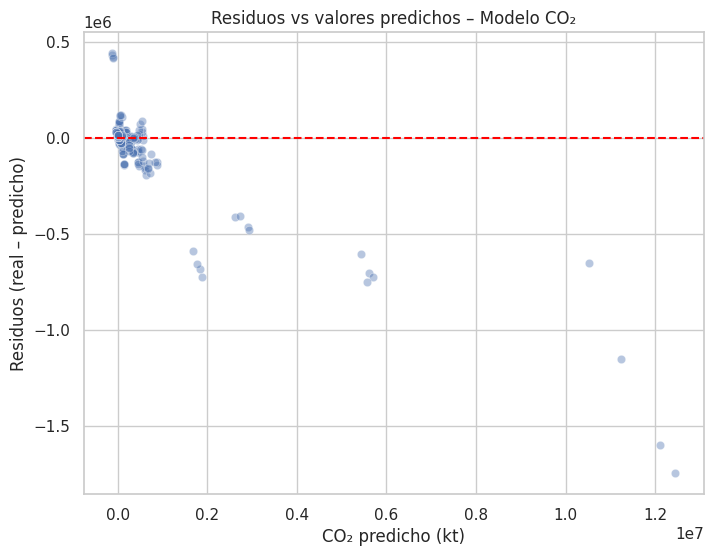

In [23]:
# Análisis de residuos – Modelo lineal CO₂

# Los residuos son la diferencia entre el valor real y el predicho
# Si el modelo es bueno, deberían estar centrados en cero y sin ningún patrón visible
residuals_co2 = y_test_co2 - y_pred_co2

# Gráfico de residuos vs valores predichos:
# si hay un patrón (embudo, curva), indica problemas en el modelo
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_co2, y=residuals_co2, alpha=0.4)

# Línea horizontal en y=0: los residuos deberían distribuirse simétricamente alrededor de ella
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("CO₂ predicho (kt)")
plt.ylabel("Residuos (real – predicho)")
plt.title("Residuos vs valores predichos – Modelo CO₂")
plt.show()

El gráfico de residuos muestra que están centrados en cero, lo cual es buena señal, no hay un sesgo sistemático en las predicciones. Para cuantificar los dos patrones habituales en este tipo de datos (heterocedasticidad y autocorrelación temporal) se realizan a continuación dos tests formales.

In [24]:
# Diagnóstico formal de residuos – Modelo CO₂
# Dos tests para cuantificar los patrones observados en el gráfico de residuos:

# Test de Breusch-Pagan (heterocedasticidad)
# Contrasta si la varianza de los residuos es constante (homocedasticidad)
# o varía en función de los predictores (heterocedasticidad).
# Regresa los residuos al cuadrado sobre las variables explicativas y calcula
# el estadístico LM = n × R² de esa regresión auxiliar.
# Un p-valor < 0.05 indica heterocedasticidad.
# Usamos las variables escaladas (X_test_co2_scaled), que son las que el modelo ha visto.
# sm.add_constant añade una columna de unos necesaria para la regresión auxiliar interna del test
lm_co2, p_bp_co2, _, _ = het_breuschpagan(residuals_co2, sm.add_constant(X_test_co2_scaled))

print("Test de Breusch-Pagan (heterocedasticidad)")
print(f"Estadístico LM: {lm_co2:.3f}")
print(f"p-valor:        {p_bp_co2:.4f}")
print()

# Test de Durbin-Watson (autocorrelación temporal)
# Detecta si los residuos consecutivos están correlacionados entre sí.
# Valor ideal = 2 (sin autocorrelación);
# Valores < 1.5 indican autocorrelación positiva (habitual en panel data)
dw_co2 = durbin_watson(residuals_co2)

print("Test de Durbin-Watson (autocorrelación)")
print(f"Estadístico DW: {dw_co2:.3f}  (valor ideal = 2)")

Test de Breusch-Pagan (heterocedasticidad)
Estadístico LM: 496.219
p-valor:        0.0000

Test de Durbin-Watson (autocorrelación)
Estadístico DW: 0.532  (valor ideal = 2)


**Heterocedasticidad (Breusch-Pagan):** el estadístico LM = 496,2 con p < 0,001 rechaza claramente la hipótesis nula de homocedasticidad. Hay heterocedasticidad: la varianza de los residuos no es constante sino que aumenta con el nivel de emisiones predichas. Los países con mayores emisiones (China, EE.UU., India) generan errores más grandes, lo cual es esperable dado que son también las economías estructuralmente más complejas y difíciles de modelar.

**Autocorrelación temporal (Durbin-Watson):** el estadístico DW = 0,53 está muy por debajo del valor ideal de 2, lo que confirma autocorrelación positiva en los residuos. Los errores de un mismo país en años consecutivos se parecen entre sí, algo común en la estructura de panel data.

---
**Notas adicionales**

Ambos constituyen limitaciones del modelo lineal para inferencia estadística: si quisiéramos calcular p-valores o intervalos de confianza sobre los coeficientes, estos serían poco fiables. Sin embargo, dado que el objetivo de este trabajo es predictivo, estimar emisiones a partir de variables del sistema energético —, ninguno de los dos invalida las métricas de evaluación (R², MAE, RMSE) ni las conclusiones del estudio.

### 9.7 Ridge Regression

Ridge es una versión regularizada de la regresión lineal. Añade un término de penalización al proceso de estimación que fuerza a los coeficientes a ser más pequeños. El parámetro α controla la fuerza de esa penalización: α=0 es exactamente igual a la regresión lineal estándar, y cuanto mayor es α más se penalizan los coeficientes. El objetivo es reducir el sobreajuste cuando los predictores están correlacionados entre sí.

La estandarización aplicada en la celda de preparación de datos es especialmente importante para Ridge: si las variables tuvieran escalas distintas, la penalización actuaría de forma desigual sobre los coeficientes, castigando más a las variables con valores grandes independientemente de su importancia real. Al estandarizar previamente, todos los coeficientes se comparan en la misma escala y la regularización es equitativa.

Para encontrar el mejor α se usa GridSearchCV con validación cruzada de 5 folds. Esto entrena el modelo con distintos valores de α y se queda con el que da mejor R² en promedio en los 5 folds de validación. Así, elegimos el parámetro de forma objetiva y no a ojo.

In [25]:
# Ridge Regression – Modelo CO₂

# Los datos ya están estandarizados desde la celda de preparación,
# por lo que Ridge recibe directamente X_train_co2_scaled y X_test_co2_scaled.
# El GridSearchCV busca el mejor valor de α (fuerza de regularización)
# mediante validación cruzada de 5 folds sobre el conjunto de entrenamiento.
# α=0 equivale a regresión lineal; cuanto mayor es α, más se penalizan
# los coeficientes hacia cero.
grid_ridge_co2 = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1, 10, 100, 1000]},
    cv=5,
    scoring="r2"
)

# Entrenamos el GridSearchCV: busca el mejor α y entrena el modelo final con ese α
grid_ridge_co2.fit(X_train_co2_scaled, y_train_co2)

# best_estimator_ es el modelo con el mejor α encontrado
best_ridge = grid_ridge_co2.best_estimator_

# Aplicamos el modelo al test
y_pred_ridge = best_ridge.predict(X_test_co2_scaled)

r2_ridge   = r2_score(y_test_co2, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test_co2, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_co2, y_pred_ridge))

print("Mejor α:", grid_ridge_co2.best_params_)
print("R²:  ", round(r2_ridge, 4))
print("MAE: ", round(mae_ridge, 0), "kt")
print("RMSE:", round(rmse_ridge, 0), "kt")

Mejor α: {'alpha': 0.01}
R²:   0.9748
MAE:  49746.0 kt
RMSE: 145583.0 kt


In [26]:
# Coeficientes Ridge – Modelo CO₂

# Los coeficientes se acceden directamente desde best_ridge
ridge_coefs = best_ridge.coef_

coef_df_ridge = pd.DataFrame({
    "Feature": features_co2_final,
    "Ridge Coefficient": ridge_coefs
})

print(coef_df_ridge)

                                             Feature  Ridge Coefficient
0                                               Year       -8563.156696
1                Electricity from fossil fuels (TWh)      704068.375854
2                     Electricity from nuclear (TWh)      -59326.019231
3                  Electricity from renewables (TWh)       73415.601548
4  Renewable energy share in the total final ener...       -4914.121515
5             Low-carbon electricity (% electricity)        7890.054315
6  Energy intensity level of primary energy (MJ/$...        8998.721337


#### 9.8 Resultados Ridge


Ridge no mejora respecto a la regresión lineal. El mejor α es 0,01, que es prácticamente cero, lo que significa que la regularización óptima es casi no regularizar. Esto indica que los coeficientes del modelo lineal ya son estables y no necesitan penalización.

### 9.9 Random Forest – Modelo CO₂

Se prueba un modelo de Random Forest como modelo no lineal, con el objetivo de comprobar si hay relaciones no lineales que los demás modelos no estén capturando.

---
**Notas adicionales**

Random Forest es un modelo que construye muchos árboles de decisión (en nuestro caso, 300) sobre muestras aleatorias de los datos, y el resultado final es la media de las predicciones de todos los árboles. Esto lo hace más robusto que un solo árbol y menos propenso al sobreajuste. El parámetro max_depth controla la profundidad máxima de cada árbol: sin límite (None), los árboles crecen hasta separar perfectamente el conjunto de entrenamiento, lo que puede causar sobreajuste. Por eso se optimiza con GridSearchCV.

In [27]:
# Random Forest – Modelo CO₂

# Random Forest es invariante a la escala de las variables (los árboles de decisión
# trabajan con umbrales, no con magnitudes), por lo que el escalado no cambia el resultado.
# De todas formas, usamos X_train_co2_scaled por coherencia metodológica con los otros modelos.

# Definimos los valores de max_depth que queremos probar
# max_depth controla la profundidad máxima de cada árbol:
# - valores pequeños (5, 10): árboles sencillos, menos riesgo de sobreajuste pero menos precisos
# - None: los árboles crecen sin límite, pueden memorizar el entrenamiento (sobreajuste)
# GridSearchCV elegirá el que mejor generalice en validación cruzada
param_grid_rf_co2 = {
    "max_depth": [5, 10, 15, 20, None]
}

# n_estimators=300: construimos 300 árboles de decisión distintos
# Más árboles = más estabilidad, pero más tiempo de cómputo
# random_state=42: fija la semilla aleatoria para que los resultados sean reproducibles
# n_jobs=-1: usa todos los núcleos del procesador en paralelo para ir más rápido
rf_co2_base = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Buscamos el mejor max_depth con validación cruzada de 5 folds
grid_rf_co2 = GridSearchCV(
    rf_co2_base,
    param_grid_rf_co2,
    cv=5,
    scoring="r2"
)

grid_rf_co2.fit(X_train_co2_scaled, y_train_co2)
rf_co2 = grid_rf_co2.best_estimator_   # modelo final con el mejor max_depth

y_pred_rf = rf_co2.predict(X_test_co2_scaled)

r2_rf   = r2_score(y_test_co2, y_pred_rf)
mae_rf  = mean_absolute_error(y_test_co2, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_co2, y_pred_rf))

print("Mejor max_depth:", grid_rf_co2.best_params_)
print("R²:  ", round(r2_rf, 4))
print("MAE: ", round(mae_rf, 0), "kt")
print("RMSE:", round(rmse_rf, 0), "kt")

Mejor max_depth: {'max_depth': 15}
R²:   0.897
MAE:  47011.0 kt
RMSE: 294371.0 kt


#### 9.10 Importancia de variables (Random Forest)

In [28]:
# Importancia de variables – Random Forest CO₂

# feature_importances_ devuelve un array con la importancia de cada variable
# La importancia mide cuánto reduce el error de predicción cada variable
# en promedio a lo largo de todos los árboles del bosque
# Los valores suman 1
importances = rf_co2.feature_importances_

# DataFrame para verlo más claro
importance_df = pd.DataFrame({
    "Feature": features_co2_final,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)   # ordenamos de más a menos importante

print(importance_df)

                                             Feature  Importance
1                Electricity from fossil fuels (TWh)    0.938471
3                  Electricity from renewables (TWh)    0.047307
4  Renewable energy share in the total final ener...    0.005471
2                     Electricity from nuclear (TWh)    0.003200
5             Low-carbon electricity (% electricity)    0.002917
6  Energy intensity level of primary energy (MJ/$...    0.001540
0                                               Year    0.001093


#### 9.11 Resultados Random Forest

El Random Forest obtiene un R² inferior al modelo lineal (0,897 vs 0,975). La importancia de variables confirma que más del 94% del poder predictivo del modelo recae sobre la generación fósil. Todo esto apunta en la misma dirección: la relación entre fósiles y CO₂ es tan lineal y dominante que un modelo no lineal no añade nada.

---
**Notas adicionales**

La importancia de variables en Random Forest mide cuánto reduce el error de predicción cada variable en promedio a lo largo de todos los árboles. No es lo mismo que el coeficiente de la regresión lineal: no dice cuánto cambia el objetivo por unidad de predictor, sino qué porcentaje del poder predictivo total aporta esa variable.

### 9.12 Comparación de modelos (con generación fósil)

| Modelo | R² | MAE (kt) | RMSE (kt) |
|--------|-----|----------|-----------|
| Regresión Lineal | 0,9748 | 49.746 | 145.583 |
| Ridge (α=0,01) | 0,9748 | 49.746 | 145.583 |
| Random Forest (depth=15) | 0,8970 | 47.011 | 294.371 |

Los tres modelos confirman la misma historia: la relación entre generación fósil y emisiones de CO₂ es esencialmente lineal. Regresión lineal y Ridge dan resultados idénticos — el α óptimo de 0,01 es prácticamente cero, lo que significa que la regularización no es necesaria porque los coeficientes ya son estables. El Random Forest obtiene un R² inferior (0,897 vs 0,975), lo que indica que un modelo no lineal no aporta ventaja cuando la relación subyacente es lineal. El RMSE considerablemente más alto del RF (294.371 vs 145.583 kt) refleja que comete errores más grandes en los países con emisiones extremas, que son precisamente los más difíciles de predecir.

### 9.13 Conclusión (primer modelo)

Los tres modelos son consistentes: la generación fósil explica prácticamente todo en este modelo. Incluir una variable con correlación r ≈ 0,99 con el objetivo hace que el modelo sea preciso, pero no está aprendiendo ninguna estructura estadística interesante, solo reproduciendo una relación física casi directa. Por eso se procede a  construir el modelo revisado, eliminando la columna de electricity from fossil fuels.

### 9.14 Modelo CO₂ revisado — sin generación fósil

Para construir un modelo con mayor valor predictivo real, se excluye la variable fósil y se trabaja con el resto de predictores estructurales del sistema energético.


In [29]:
# Preparación de datos – Modelo CO₂ revisado (sin generación fósil)

features_co2_revised = [
    "Year",
    "Electricity from nuclear (TWh)",
    "Electricity from renewables (TWh)",
    "Renewable energy share in the total final energy consumption (%)",
    "Low-carbon electricity (% electricity)",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)"
]

target_co2 = "Value_co2_emissions_kt_by_country"

# Misma división temporal que el modelo original
X_train_co2_rev = train_df[features_co2_revised]
y_train_co2_rev = train_df[target_co2]

X_test_co2_rev = test_df[features_co2_revised]
y_test_co2_rev = test_df[target_co2]

# Estandarización — mismo criterio que el modelo original:
# el scaler se ajusta con el train y se aplica al test sin reajustar
scaler_co2_rev = StandardScaler()
X_train_co2_rev_scaled = scaler_co2_rev.fit_transform(X_train_co2_rev)
X_test_co2_rev_scaled  = scaler_co2_rev.transform(X_test_co2_rev)

print("Train shape:", X_train_co2_rev_scaled.shape)
print("Test shape:", X_test_co2_rev_scaled.shape)

Train shape: (2581, 6)
Test shape: (640, 6)


In [30]:
# Regresión lineal – Modelo CO₂ revisado

# Seguimos el mismo procedimiento que para el modelo original:
# creamos el objeto, lo entrenamos con .fit(), predecimos con .predict() y calculamos métricas
linreg_co2_rev = LinearRegression()
linreg_co2_rev.fit(X_train_co2_rev_scaled, y_train_co2_rev)

y_pred_co2_rev = linreg_co2_rev.predict(X_test_co2_rev_scaled)

r2_co2_rev   = r2_score(y_test_co2_rev, y_pred_co2_rev)
mae_co2_rev  = mean_absolute_error(y_test_co2_rev, y_pred_co2_rev)
rmse_co2_rev = np.sqrt(mean_squared_error(y_test_co2_rev, y_pred_co2_rev))

print("Regresión Lineal – Modelo CO₂ revisado")
print("R²:  ", round(r2_co2_rev, 4))
print("MAE: ", round(mae_co2_rev, 0), "kt")
print("RMSE:", round(rmse_co2_rev, 0), "kt")

Regresión Lineal – Modelo CO₂ revisado
R²:   0.8048
MAE:  163546.0 kt
RMSE: 405271.0 kt


In [31]:
# Ridge Regression – Modelo CO₂ revisado

grid_ridge_rev = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1, 10, 100, 1000]},
    cv=5,
    scoring="r2"
)

grid_ridge_rev.fit(X_train_co2_rev_scaled, y_train_co2_rev)
best_ridge_rev = grid_ridge_rev.best_estimator_

y_pred_ridge_rev = best_ridge_rev.predict(X_test_co2_rev_scaled)

r2_ridge_rev   = r2_score(y_test_co2_rev, y_pred_ridge_rev)
mae_ridge_rev  = mean_absolute_error(y_test_co2_rev, y_pred_ridge_rev)
rmse_ridge_rev = np.sqrt(mean_squared_error(y_test_co2_rev, y_pred_ridge_rev))

print("Mejor α:", grid_ridge_rev.best_params_)
print("R²:  ", round(r2_ridge_rev, 4))
print("MAE: ", round(mae_ridge_rev, 0), "kt")
print("RMSE:", round(rmse_ridge_rev, 0), "kt")

Mejor α: {'alpha': 1000}
R²:   0.9086
MAE:  114106.0 kt
RMSE: 277366.0 kt


In [32]:
# Random Forest – Modelo CO₂ revisado

param_grid_rf_co2_rev = {
    "max_depth": [5, 10, 15, 20, None]
}

rf_co2_rev_base = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

grid_rf_co2_rev = GridSearchCV(
    rf_co2_rev_base,
    param_grid_rf_co2_rev,
    cv=5,
    scoring="r2"
)

grid_rf_co2_rev.fit(X_train_co2_rev_scaled, y_train_co2_rev)
rf_co2_rev = grid_rf_co2_rev.best_estimator_

y_pred_rf_rev = rf_co2_rev.predict(X_test_co2_rev_scaled)

r2_rf_rev   = r2_score(y_test_co2_rev, y_pred_rf_rev)
mae_rf_rev  = mean_absolute_error(y_test_co2_rev, y_pred_rf_rev)
rmse_rf_rev = np.sqrt(mean_squared_error(y_test_co2_rev, y_pred_rf_rev))

print("Mejor max_depth:", grid_rf_co2_rev.best_params_)
print("R²:  ", round(r2_rf_rev, 4))
print("MAE: ", round(mae_rf_rev, 0), "kt")
print("RMSE:", round(rmse_rf_rev, 0), "kt")

# Importancia de variables del modelo revisado
importances_rev = pd.DataFrame({
    "Feature": features_co2_revised,
    "Importance": rf_co2_rev.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nImportancia de variables:")
print(importances_rev.to_string(index=False))

Mejor max_depth: {'max_depth': 20}
R²:   0.8756
MAE:  54697.0 kt
RMSE: 323585.0 kt

Importancia de variables:
                                                         Feature  Importance
                               Electricity from renewables (TWh)    0.644149
                                  Electricity from nuclear (TWh)    0.174033
                          Low-carbon electricity (% electricity)    0.074699
Renewable energy share in the total final energy consumption (%)    0.055899
     Energy intensity level of primary energy (MJ/$2017 PPP GDP)    0.048357
                                                            Year    0.002863


### 9.15 Comparación de modelos (sin generación fósil)

| Modelo | R² | MAE (kt) | RMSE (kt) |
|--------|-----|----------|-----------|
| Regresión Lineal | 0,8048 | 163.546 | 405.271 |
| Ridge (α=1000) | 0,9086 | 114.106 | 277.366 |
| Random Forest (depth=20) | 0,8756 | 54.697 | 323.585 |

Al quitar la variable fósil, el rendimiento baja como era de esperar. Pero los resultados siguen siendo razonables, lo que confirma que el resto de variables sí aportan información genuina sobre las emisiones. En este modelo revisado, Ridge es el mejor en R² y RMSE. Que el α óptimo sea 1000 (penalización fuerte) tiene sentido: sin el predictor dominante los coeficientes son menos estables y la regularización influye más.

La importancia de variables del Random Forest muestra que ahora la generación renovable pasa a ser el predictor principal (64%), seguida de nuclear (17%) y la proporción de electricidad baja en carbono (7,5%).


## 10. MODELADO PREDICTIVO – MODELO B: CONSUMO ENERGÉTICO PER CÁPITA

### 10.1 Planteamiento

El segundo modelo predice el consumo energético por habitante en kWh/habitante. Esta variable es más compleja de predecir que las emisiones de CO₂ porque depende de múltiples factores económicos y estructurales que interactúan entre sí de formas no necesariamente lineales.

Por ejemplo, la relación entre PIB per cápita y consumo energético no es lineal: en países muy pobres el consumo crece mucho con el aumento de la renta, pero, a partir de cierto nivel de desarrollo, el crecimiento se ralentiza. Esto se conoce como la curva de Kuznets energética. Este tipo de relaciones con umbrales e interacciones más complejas son seguramente lo que Random Forest puede modelar mejor que la regresión lineal en nuestro estudio.

Se prueban los mismos tres algoritmos que en el modelo de CO₂.

### 10.2 Preparación de datos

**Nota para la memoria**

El hecho de que los dos modelos usen la misma división temporal es importante para que los resultados sean comparables entre sí. Si uno usara una división temporal y el otro una aleatoria, no se podría comparar directamente su rendimiento.

In [33]:
# Preparación de datos – Modelo de consumo energético per cápita

features_energy_final = [
   "gdp_per_capita",
    "gdp_growth",
    "Electricity from fossil fuels (TWh)",
    "Electricity from nuclear (TWh)",
    "Electricity from renewables (TWh)",
    "Renewable energy share in the total final energy consumption (%)",
    "Low-carbon electricity (% electricity)",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)",
    "Access to electricity (% of population)",
    "Land Area(Km2)"
]

target_energy = "Primary energy consumption per capita (kWh/person)"

# Misma división temporal que el modelo de CO₂
train_df = df[df["Year"] <= 2015]
test_df  = df[df["Year"] > 2015]

X_train_energy = train_df[features_energy_final]
y_train_energy = train_df[target_energy]

X_test_energy = test_df[features_energy_final]
y_test_energy = test_df[target_energy]

# Estandarización — mismo criterio que el modelo de CO₂
# Especialmente importante para Ridge, pero se aplica a todos los modelos
scaler_energy = StandardScaler()
X_train_energy_scaled = scaler_energy.fit_transform(X_train_energy)
X_test_energy_scaled  = scaler_energy.transform(X_test_energy)

print("Train shape:", X_train_energy_scaled.shape)
print("Test shape:", X_test_energy_scaled.shape)

Train shape: (2581, 10)
Test shape: (640, 10)


### 10.3 Regresión lineal múltiple

In [34]:
# Regresión lineal – Modelo de energía per cápita

# Mismo esquema que el modelo de CO₂: fit → predict → métricas
linreg_energy = LinearRegression()
linreg_energy.fit(X_train_energy_scaled, y_train_energy)

y_pred_energy = linreg_energy.predict(X_test_energy_scaled)

r2_energy   = r2_score(y_test_energy, y_pred_energy)
mae_energy  = mean_absolute_error(y_test_energy, y_pred_energy)
rmse_energy = np.sqrt(mean_squared_error(y_test_energy, y_pred_energy))

print("Regresión Lineal – Modelo de energía")
print("R²:  ", round(r2_energy, 4))
print("MAE: ", round(mae_energy, 0), "kWh/persona")
print("RMSE:", round(rmse_energy, 0), "kWh/persona")

Regresión Lineal – Modelo de energía
R²:   0.635
MAE:  12109.0 kWh/persona
RMSE: 21441.0 kWh/persona


#### 10.4 Resultados

El modelo explica el 63,5% de la variabilidad del consumo per cápita. Es un resultado razonable para un fenómeno tan complejo, pero claramente inferior al modelo de CO₂. Esto anticipa que las relaciones aquí son más difíciles de capturar con un modelo lineal.

#### 10.5 Interpretación de coeficientes

In [35]:
# Coeficientes de la regresión lineal – Modelo de energía

# linreg_energy.coef_ contiene el coeficiente de cada predictor
coef_df_energy = pd.DataFrame({
    "Variable": features_energy_final,
    "Coeficiente": linreg_energy.coef_
})

print(coef_df_energy)
print("Intercept:", linreg_energy.intercept_)

                                            Variable   Coeficiente
0                                     gdp_per_capita  21669.241080
1                                         gdp_growth   2075.264501
2                Electricity from fossil fuels (TWh)  -3598.715110
3                     Electricity from nuclear (TWh)   1474.994252
4                  Electricity from renewables (TWh)   1137.399557
5  Renewable energy share in the total final ener...  -3661.653393
6             Low-carbon electricity (% electricity)  -2536.543173
7  Energy intensity level of primary energy (MJ/$...  10863.369297
8            Access to electricity (% of population)   7242.270903
9                                     Land Area(Km2)   1936.006928
Intercept: 26485.530712246804


Los coeficientes más relevantes:

* PIB per cápita tiene el coeficiente positivo más alto en términos de magnitud (≈ +21669), lo que confirma que el nivel de desarrollo económico es el principal determinante del consumo energético por habitante. Mayor renta implica más consumo energético.
* Intensidad energética tiene también coeficiente positivo elevado (≈ +10863): mayor ineficiencia del sistema productivo se traduce en mayor consumo por habitante.
* Proporción renovable tiene coeficiente negativo (≈ -3661), coherente con la paradoja de las renovables: los países con mayor cuota renovable tienden a tener consumos per cápita más moderados.
* Acceso a electricidad (≈ +7242): países con mayor cobertura eléctrica tienen más consumo per cápita.

#### 10.6 Análisis de residuos

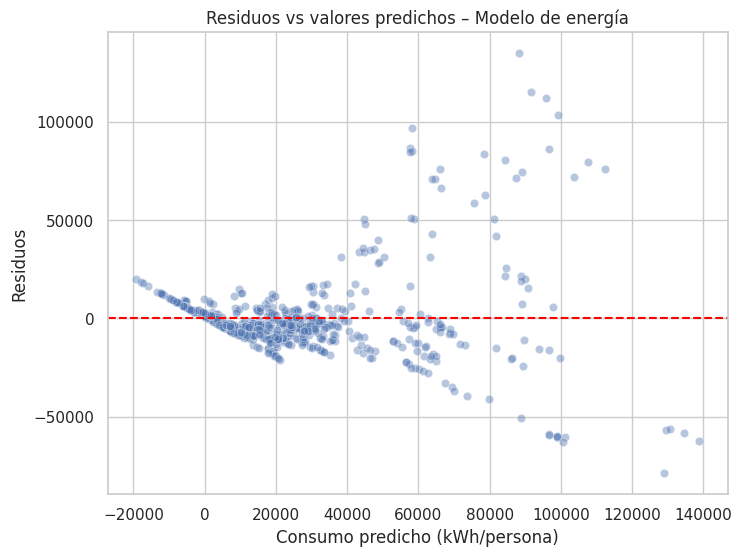

In [36]:
# Análisis de residuos – Modelo lineal de energía

# Calculamos los residuos
residuals_energy = y_test_energy - y_pred_energy

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred_energy, y=residuals_energy, alpha=0.4)

# Si el modelo es adecuado los puntos deben estar dispersos aleatoriamente alrededor de y=0
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Consumo predicho (kWh/persona)")
plt.ylabel("Residuos")
plt.title("Residuos vs valores predichos – Modelo de energía")
plt.show()

Los residuos están razonablemente centrados en cero, sin un sesgo sistemático claro. Para cuantificar los mismos patrones que en el modelo de CO₂ se aplican los mismos tests.

In [37]:
# Diagnóstico formal de residuos – Modelo de energía per cápita

# Breusch-Pagan
lm_e, p_bp_e, _, _ = het_breuschpagan(residuals_energy, sm.add_constant(X_test_energy_scaled))

print("Test de Breusch-Pagan (heterocedasticidad)")
print(f"Estadístico LM: {lm_e:.3f}")
print(f"p-valor:        {p_bp_e:.4f}")
print()

# Durbin-Watson
dw_energy = durbin_watson(residuals_energy)

print("Test de Durbin-Watson (autocorrelación)")
print(f"Estadístico DW: {dw_energy:.3f}  (valor ideal = 2)")

Test de Breusch-Pagan (heterocedasticidad)
Estadístico LM: 248.671
p-valor:        0.0000

Test de Durbin-Watson (autocorrelación)
Estadístico DW: 0.594  (valor ideal = 2)


**Heterocedasticidad (Breusch-Pagan):** el estadístico LM = 248,7 con p < 0,001 confirma heterocedasticidad también en este modelo. Los errores son sistemáticamente mayores en los extremos del rango de consumo: países con consumo muy elevado (EE.UU., Australia, ...) y países con consumo muy bajo (economías en desarrollo) son los más difíciles de predecir con un modelo lineal.

**Autocorrelación temporal (Durbin-Watson):** el estadístico DW = 0,59, también por debajo de 2, confirma autocorrelación positiva. Las mismas observaciones aplican que en el modelo de CO₂: es una característica de los datos de panel, no un defecto del modelo.

Estas limitaciones afectan a la inferencia estadística pero no a las métricas predictivas. En el contexto de este trabajo, donde el objetivo es predecir el consumo energético per cápita, ambos patrones quedan documentados como limitaciones conocidas sin que comprometan las conclusiones del estudio.

### 10.7 Ridge Regression


Se aplica el mismo procedimiento que en el modelo de CO₂: Ridge con GridSearchCV (cv=5) para encontrar el α óptimo. Las variables ya están estandarizadas desde la celda de preparación de datos, por lo que no es necesario ningún paso adicional de preprocesamiento.

In [38]:
# Ridge Regression – Modelo de energía per cápita

grid_ridge_energy = GridSearchCV(
    Ridge(),
    {"alpha": [0.01, 0.1, 1, 10, 100, 1000]},
    cv=5,
    scoring="r2"
)

grid_ridge_energy.fit(X_train_energy_scaled, y_train_energy)
best_ridge_energy = grid_ridge_energy.best_estimator_

y_pred_ridge_energy = best_ridge_energy.predict(X_test_energy_scaled)

r2_ridge_energy   = r2_score(y_test_energy, y_pred_ridge_energy)
mae_ridge_energy  = mean_absolute_error(y_test_energy, y_pred_ridge_energy)
rmse_ridge_energy = np.sqrt(mean_squared_error(y_test_energy, y_pred_ridge_energy))

print("Mejor α:", grid_ridge_energy.best_params_)
print("R²:  ", round(r2_ridge_energy, 4))
print("MAE: ", round(mae_ridge_energy, 0), "kWh/persona")
print("RMSE:", round(rmse_ridge_energy, 0), "kWh/persona")

Mejor α: {'alpha': 100}
R²:   0.6313
MAE:  12126.0 kWh/persona
RMSE: 21550.0 kWh/persona


#### 10.8 Resultados Ridge

Ridge no mejora al modelo lineal, el R² baja ligeramente de 0,635 a 0,631. El α óptimo de 100 es más alto que en el modelo de CO₂ (donde era 0,01), lo que indica que aquí sí hay algo de inestabilidad en los coeficientes. Pero la regularización no es suficiente para resolver el problema de fondo, que es que las relaciones no son lineales.

### 10.9 Random Forest – Modelo de energía


In [39]:
# Random Forest – Modelo de energía per cápita

param_grid_rf_energy = {
    "max_depth": [5, 10, 15, 20, None]
}

rf_energy_base = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

grid_rf_energy = GridSearchCV(
    rf_energy_base,
    param_grid_rf_energy,
    cv=5,
    scoring="r2"
)

grid_rf_energy.fit(X_train_energy_scaled, y_train_energy)
rf_energy = grid_rf_energy.best_estimator_

y_pred_rf_energy = rf_energy.predict(X_test_energy_scaled)

r2_rf_energy   = r2_score(y_test_energy, y_pred_rf_energy)
mae_rf_energy  = mean_absolute_error(y_test_energy, y_pred_rf_energy)
rmse_rf_energy = np.sqrt(mean_squared_error(y_test_energy, y_pred_rf_energy))

print("Mejor max_depth:", grid_rf_energy.best_params_)
print("R²:  ", round(r2_rf_energy, 4))
print("MAE: ", round(mae_rf_energy, 0), "kWh/persona")
print("RMSE:", round(rmse_rf_energy, 0), "kWh/persona")

Mejor max_depth: {'max_depth': 15}
R²:   0.9635
MAE:  3418.0 kWh/persona
RMSE: 6777.0 kWh/persona


#### 10.10 Importancia de variables (Random Forest)


Se usa el mismo esquema de GridSearchCV sobre max_depth para ser consistente con el modelo de CO₂. El mejor max_depth encontrado es 15, lo que indica que los árboles necesitan una profundidad considerable para capturar las relaciones no lineales entre las variables económicas y energéticas, pero no crecimiento ilimitado. Un max_depth de 15 ofrece un buen equilibrio entre capacidad para capturar complejidad y control del sobreajuste.

In [40]:
# Importancia de variables – Random Forest de energía

importances_energy = rf_energy.feature_importances_

importance_df_energy = pd.DataFrame({
    "Feature": features_energy_final,
    "Importance": importances_energy
}).sort_values(by="Importance", ascending=False)

print(importance_df_energy)

                                             Feature  Importance
0                                     gdp_per_capita    0.569739
7  Energy intensity level of primary energy (MJ/$...    0.186172
5  Renewable energy share in the total final ener...    0.085161
9                                     Land Area(Km2)    0.077588
2                Electricity from fossil fuels (TWh)    0.038381
8            Access to electricity (% of population)    0.014297
6             Low-carbon electricity (% electricity)    0.012101
4                  Electricity from renewables (TWh)    0.006722
3                     Electricity from nuclear (TWh)    0.005543
1                                         gdp_growth    0.004296


#### 10.11 Resultados Random Forest

El salto de rendimiento es muy grande: R² pasa de 0,635 a 0,963 y el RMSE se reduce de 21.441 a 6.777 kWh/persona. Esto confirma que hay relaciones no lineales fuertes en el consumo per cápita que la regresión lineal no puede capturar pero el Random Forest sí.

El PIB per cápita es el predictor dominante con 57% de importancia, seguido de la intensidad energética con 19%. Esto es coherente con la idea de que el nivel de desarrollo económico es el principal determinante del consumo energético individual.

### 10.12 Comparación de modelos

| Modelo | R² | MAE (kWh/p) | RMSE (kWh/p) |
|--------|-----|-------------|--------------|
| Regresión Lineal | 0,6350 | 12.109 | 21.441 |
| Ridge (α=100) | 0,6313 | 12.126 | 21.550 |
| Random Forest | 0,9635 | 3.418 | 6.777 |

La diferencia entre los modelos lineales y Random Forest es muy clara. La razón es que el consumo energético per cápita tiene relaciones no lineales con sus determinantes (umbrales, interacciones, rendimientos decrecientes) que los modelos lineales no representan.

### 10.13 Conclusión del modelo de energía

El Random Forest con R² = 0,963 es el modelo que mejor captura la dinámica del consumo per cápita y se adopta como modelo final. La regresión lineal se mantiene como referencia interpretativa porque permite leer el efecto estimado de cada variable.

## 11. VALIDACIÓN EXTERNA

### 11.1 Motivación

El dataset de Kaggle cubre el periodo 2000–2019, lo que significa que los modelos desarrollados en las secciones anteriores se entrenaron y evaluaron exclusivamente con datos de ese intervalo. Una extensión natural del trabajo era comprobar si esos modelos son capaces de predecir correctamente en años más recientes, para los que Kaggle no dispone de datos completos.

Con ese objetivo se recurrió al dataset de Our World in Data (OWID), una fuente de referencia internacional que integra datos de IEA, BP, Ember y otras instituciones, y que cubre bien el periodo 2020–2023. El planteamiento era el siguiente: reentrenar los modelos utilizando todo el periodo histórico disponible en Kaggle (2000–2019) para aprovechar al máximo la información de entrenamiento, y aplicarlos después sobre los datos de OWID para los años 2020–2023 en un conjunto de 11 países representativos: China, EE.UU., India, Japón, Alemania, Francia, España, Reino Unido, Brasil, Australia y Rusia.

Sin embargo, antes de aplicar los modelos, fue necesario comprobar si ambos datasets son compatibles, es decir, si las variables equivalentes miden lo mismo en las dos fuentes.

### 11.2 Análisis de compatibilidad entre datasets

Antes de aplicar los modelos, se realizó una comprobación rápida cruzando ambos datasets en el año 2019, presente en los dos, para verificar que las variables clave miden lo mismo en ambas fuentes.

In [41]:
# Comparación de variables clave entre Kaggle y OWID para el año 2019
# Cruzamos ambos datasets para comprobar la compatibilidad antes de aplicar los modelos

owid = pd.read_csv("owid-energy-data.csv")

countries_check = ['China', 'United States', 'India', 'Japan', 'Germany', 'France', 'Spain', 'United Kingdom', 'Brazil', 'Australia', 'Russia']
k2019 = df[df['Year'] == 2019]
o2019 = owid[owid['year'] == 2019]

# Consumo energético per cápita
# Esta es la variable objetivo del Modelo B, por lo que su compatibilidad entre fuentes
# es especialmente relevante
print("ENERGY PER CAPITA (kWh/persona)")
print(f"{'País':<22} {'Kaggle':>10} {'OWID':>10} {'Dif.%':>7}")
print("─" * 54)
for c in countries_check:
    k = k2019[k2019['Entity'] == c]
    o = o2019[o2019['country'] == c]
    if k.empty or o.empty: continue
    kv = k['Primary energy consumption per capita (kWh/person)'].values[0]
    ov = o['energy_per_capita'].values[0]
    print(f"{c:<22} {kv:>10,.0f} {ov:>10,.0f} {abs(kv-ov)/ov*100:>6.1f}%")

# Generación eléctrica fósil
# Variable predictor clave en ambos modelos
print()
print("GENERACIÓN ELÉCTRICA FÓSIL (TWh)")
print(f"{'País':<22} {'Kaggle':>10} {'OWID':>10} {'Dif.%':>7}")
print("─" * 54)
for c in countries_check:
    k = k2019[k2019['Entity'] == c]
    o = o2019[o2019['country'] == c]
    if k.empty or o.empty: continue
    kv = k['Electricity from fossil fuels (TWh)'].values[0]
    ov = o['fossil_electricity'].values[0]
    print(f"{c:<22} {kv:>10,.1f} {ov:>10,.1f} {abs(kv-ov)/ov*100:>6.1f}%")

# GDP per cápita
# Principal predictor del Modelo B (57% de importancia en RF)
print()
print("GDP PER CÁPITA (USD)")
print(f"{'País':<22} {'Kaggle':>10} {'OWID':>10} {'Dif.%':>7}")
print("─" * 54)
for c in countries_check:
    k = k2019[k2019['Entity'] == c]
    o = o2019[o2019['country'] == c]
    if k.empty or o.empty: continue
    kv = k['gdp_per_capita'].values[0]
    ov = o['gdp'].values[0] / o['population'].values[0]
    print(f"{c:<22} {kv:>10,.0f} {ov:>10,.0f} {abs(kv-ov)/ov*100:>6.1f}%")

# Intensidad energética
# Segunda variable más importante del Modelo B (19% de importancia en RF)
# El denominador (PIB) se mide distinto en cada fuente, por lo que se muestra
# el factor de escala en lugar de la diferencia porcentual
print()
print("ENERGY INTENSITY (MJ/$GDP)")
print(f"{'País':<22} {'Kaggle':>10} {'OWID':>10} {'Factor':>8}")
print("─" * 54)
for c in countries_check:
    k = k2019[k2019['Entity'] == c]
    o = o2019[o2019['country'] == c]
    if k.empty or o.empty: continue
    kv = k['Energy intensity level of primary energy (MJ/$2017 PPP GDP)'].values[0]
    ov = o['energy_per_gdp'].values[0]
    print(f"{c:<22} {kv:>10.2f} {ov:>10.2f} {kv/ov:>8.1f}x")

ENERGY PER CAPITA (kWh/persona)
País                       Kaggle       OWID   Dif.%
──────────────────────────────────────────────────────
China                      28,277     28,232    0.2%
United States              79,489     78,683    1.0%
India                       6,732      6,682    0.7%
Japan                      40,869     41,086    0.5%
Germany                    44,468     44,923    1.0%
France                     42,327     41,554    1.9%
Spain                      33,765     33,390    1.1%
United Kingdom             32,894     32,677    0.7%
Brazil                     16,682     17,194    3.0%
Australia                  66,264     65,939    0.5%

GENERACIÓN ELÉCTRICA FÓSIL (TWh)
País                       Kaggle       OWID   Dif.%
──────────────────────────────────────────────────────
China                     5,098.2    5,140.1    0.8%
United States             2,588.2    2,588.2    0.0%
India                     1,273.6    1,273.8    0.0%
Japan                       7

Los resultados muestran tres situaciones distintas:

- Variables eléctricas (generación fósil, nuclear, renovables) y consumo per cápita: coinciden bien entre fuentes, con diferencias inferiores al 3% en la mayoría de países. Ambos datasets usan las mismas fuentes primarias  para estos datos.

- GDP per cápita: aquí encontramos diferencias importantes en economías emergentes (India 70%, China 39%, Brasil 40%). Kaggle usa PIB en dólares corrientes o nominales, mientras que OWID lo calcula en dólares constantes de 2017 en paridad de poder adquisitivo (PPP). Son dos formas válidas de medir el PIB pero en escalas distintas, lo que afecta a los datos especialmente en economías donde la diferencia entre PIB nominal y PPP es grande.

- Intensidad energética (MJ/$GDP): aquí hay una discrepancia sistemática de escala en todos los países, con un factor de entre 2,8x y 4,4x. La razón es la misma: el denominador (PIB) se mide de forma distinta en cada fuente, por lo que el ratio energía/PIB da valores completamente distintos aunque la energía consumida sea la misma.

Para el modelo de CO₂ existe además una incompatibilidad adicional: OWID no dispone de una variable equivalente a las emisiones de CO₂ del sector energético. Solo tiene `greenhouse_gas_emissions`, que incluye todos los gases de efecto invernadero (CO₂ + metano + óxido nitroso + otros) y está en unidades distintas (Mt CO₂e vs kt CO₂). La ratio entre ambas variables no es constante entre países, lo que hace imposible una comparación numérica directa.

### 11.3 Conclusión: validación externa no viable sin armonización previa

Las dos variables con mayor importancia en el modelo de energía per cápita son precisamente las que presentan mayor incompatibilidad entre fuentes: el PIB per cápita (57% de importancia en Random Forest) y la intensidad energética (19%). Cuando el modelo recibe valores de PIB e intensidad en una escala completamente distinta a la que vio durante el entrenamiento, las predicciones son incorrectas aunque el modelo en sí sea correcto.

Una validación externa rigurosa requeriría armonizar previamente ambas fuentes: unificar las definiciones de GDP (nominal vs PPP), recalcular la intensidad energética con el mismo denominador, y disponer de una variable de emisiones comparable. Este proceso queda, sin embargo, fuera del alcance de este trabajo.

La validación de los modelos queda apoyada por tanto en la validación interna ya realizada en las secciones 9 y 10, con el entrenamiento con las observaciones hasta 2015 y la evaluación sobre los de 2016–2019, todos los datos proveniendo de nuestro primer dataset de Kaggle. Esa validación es sólida y los resultados obtenidos (R²=0,91 para el modelo de CO₂ revisado, R²=0,963 para el modelo de energía) ya son representativos de la capacidad real de los modelos.

Este ejercicio tiene, no obstante, un valor metodológico propio, ilustrando una limitación frecuente en aplicaciones de machine learning, donde los cambios entre distintas fuentes de datos pueden complicar las predicciones aunque el modelado esté llevado a cabo adecuadamente.

## 12. DISCUSIÓN DE RESULTADOS

Los resultados del análisis muestran diferencias claras entre la dinámica de las emisiones de CO₂ y la del consumo energético per cápita, que se reflejan directamente en qué tipo de modelo funciona mejor para cada caso.

Para las emisiones de CO₂, el análisis inicial confirmó la estrecha relación entre generación fósil y emisiones (r ≈ 0,99). El modelo confirmatorio alcanza R² = 0,975, pero su utilidad es limitada por tratarse de una relación casi redundante. El modelo revisado, que excluye esa variable, alcanza R² = 0.91 con Ridge y ofrece una visión más genuina de los factores estructurales: la composición del mix eléctrico (renovables, nuclear) y la intensidad energética de la economía son los principales determinantes de las emisiones cuando se elimina electricity from fossil fuels.

Para el consumo energético per cápita, la regresión lineal explica solo el 63% de la variabilidad. El Random Forest mejora hasta R² = 0.963, confirmando la existencia de relaciones no lineales fuertes, especialmente la relación entre PIB per cápita y consumo (curva de Kuznets energética). El PIB per cápita explica el 57% de la importancia del modelo, lo que indica que el nivel de desarrollo económico es el factor más determinante del consumo energético individual.

Ambos modelos se evalúan mediante validación interna temporal, entrenando con datos hasta 2015 y evaluando sobre 2016–2019 de la misma fuente. Esta estrategia de división temporal es la adecuada para evitar la fuga de datos que introduciría una división aleatoria de nuestro dataset.

Respecto a la extensión temporal de los modelos, se intentó aplicarlos sobre datos de Our World in Data para el periodo 2020–2023. Sin embargo, el análisis de compatibilidad entre fuentes reveló diferencias de escala sistemáticas en las variables que hacen inviable la comparación numérica directa sin una armonización previa de fuentes, que queda fuera del alcance de este trabajo. Este hallazgo es en sí mismo un resultado relevante: ilustra la sensibilidad de los modelos a la definición y escala de las variables de entrada.

## 13. CONCLUSIONES

Este trabajo ha analizado el sistema energético global entre 2000 y 2019 usando análisis exploratorio de datos y modelos de aprendizaje automático sobre un panel de datos de múltiples países.

Las principales conclusiones son:

1. Las emisiones de CO₂ tienen una relación esencialmente lineal con la composición del sistema eléctrico. El modelo revisado (Ridge sin fósiles, R² = 0,91) confirma que la generación renovable, la nuclear y la intensidad energética son los predictores estructurales más relevantes cuando se elimina la relación casi tautológica con la generación fósil.

2. El consumo energético per cápita está determinado principalmente por el nivel de desarrollo económico (PIB per cápita, 57% de importancia en RF). Su dinámica es no lineal, coherente con la existencia de umbrales y rendimientos decrecientes en la relación renta–energía. El Random Forest (R² = 0,963) captura esta complejidad de forma efectiva.

3. El intento de extensión temporal mediante datos de OWID (2020–2023) no fue viable por incompatibilidad de escala entre fuentes en las variables clave. Este resultado pone de manifiesto que la portabilidad de los modelos entre fuentes de datos requiere una armonización previa rigurosa, algo que en la práctica constituye una de las principales dificultades en proyectos de ciencia de datos aplicada.

4. Desde una perspectiva de ingeniería, los resultados confirman que reducir las emisiones requiere actuar sobre la composición del mix eléctrico (menos fósiles, más renovables y nuclear) y mejorar la eficiencia energética de nuestros sistemas productivos.

## 14. LIMITACIONES DEL ESTUDIO

- Los datos están agregados a nivel país, lo que oculta diferencias entre sectores económicos (industria, transporte, residencial tienen dinámicas muy distintas).
- No se dispone de variables como precios de la energía, políticas energéticas concretas o innovación tecnológica, que podrían mejorar la capacidad predictiva.
- Los modelos se entrenaron con datos hasta 2019. Un periodo de validación más reciente requeriría datos de fuentes compatibles con el dataset de entrenamiento.
- La heterocedasticidad en los modelos lineales limita la validez de la inferencia sobre los coeficientes, aunque no afecta a las métricas predictivas que son el objetivo principal del trabajo.
- Hay autocorrelación temporal en los residuos (DW ≈ 0,53–0,59) inherente a la estructura de panel data, que también sería relevante si se quisiese hacer inferencia estadística sobre los coeficientes.
- Los modelos son sensibles a la definición y escala de las variables de entrada, como se mostró en la sección 11. Esto limita la portabilidad directa de los modelos a otras fuentes.
- Los modelos empleados tienen carácter estadístico y no incorporan principios físicos ni termodinámicos. La interpretación causal de los resultados debe verse con cautela.

## 15. LÍNEAS FUTURAS DE INVESTIGACIÓN

- Ampliar el conjunto de variables con precios de la energía, capacidad instalada renovable, inversión en infraestructuras o grado de electrificación.
- Desarrollar modelos específicos por sector (generación eléctrica, transporte, industria, residencial) para capturar con más detalle las fuentes de consumo y emisiones.
- Aplicar técnicas más avanzadas como Gradient Boosting (XGBoost, LightGBM) o redes neuronales para capturar relaciones más complejas.
- Realizar una armonización completa entre el dataset de Kaggle y OWID (u otras fuentes internacionales) para permitir la extensión temporal de los modelos a periodos más recientes. Esto implicaría unificar las definiciones de GDP (nominal vs PPP), recalcular la intensidad energética con el mismo denominador y asegurar la equivalencia de las variables de emisiones entre fuentes.